In [3]:
# ==========================================
# CELL 1: ALIBABA TRACE PREPROCESSOR
# ==========================================
import pandas as pd
import numpy as np
import logging
from typing import List, Dict, Tuple
from dataclasses import dataclass, field

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

@dataclass
class Processor:
    id: int
    original_id: str
    x: int
    y: int
    idle_power: float = 0.1
    speed: float = 1.0

@dataclass
class Task:
    id: str
    c_w: float
    arrival_time: float
    successors: Dict[str, float] = field(default_factory=dict)
    predecessors: Dict[str, float] = field(default_factory=dict)
    pr: float = 0.0

class AlibabaTracePreprocessor:
    def __init__(self, machine_meta_path, batch_task_path, batch_instance_path):
        self.machine_meta_path = machine_meta_path
        self.batch_task_path = batch_task_path
        self.batch_instance_path = batch_instance_path

    def load_processors(self, sample_size=None):
        logging.info("Loading processor metadata...")
        machine_cols = ['machine_id','time_stamp','failure_domain_1',
                        'failure_domain_2','cpu_num','mem_size','status']
        df = pd.read_csv(self.machine_meta_path, header=None, names=machine_cols)
        df = df.dropna(subset=['machine_id','cpu_num'])
        if 'status' in df.columns:
            df = df[df['status'] != 'terminated']
        if sample_size:
            df = df.head(sample_size)
        processors, machine_map, rack_counters = [], {}, {}
        for numeric_id, (_, row) in enumerate(df.iterrows()):
            orig_id = str(row['machine_id'])
            fd1 = row.get('failure_domain_1', 0)
            x_coord = int(fd1) if pd.notna(fd1) else 0
            y_coord = rack_counters.get(x_coord, 0)
            rack_counters[x_coord] = y_coord + 1
            cpu_cores = float(row['cpu_num']) / 100.0
            speed = max(0.5, cpu_cores)
            processors.append(Processor(
                id=numeric_id, original_id=orig_id,
                x=x_coord, y=y_coord,
                idle_power=0.1 + cpu_cores * 0.05, speed=speed
            ))
            machine_map[orig_id] = numeric_id
        logging.info(f"Generated {len(processors)} Processors.")
        return processors, machine_map

    def load_job_dag(self, target_job_name):
        logging.info(f"Extracting DAG for Job: {target_job_name}")
        task_cols = ['task_name','instance_num','job_name','task_type',
                     'status','start_time','end_time','plan_cpu','plan_mem']
        df_tasks = pd.read_csv(self.batch_task_path, header=None, names=task_cols)
        job_tasks = df_tasks[df_tasks['job_name'] == target_job_name].copy()
        job_instances = pd.read_parquet(
            self.batch_instance_path, engine='pyarrow',
            filters=[('job_name','==', target_job_name)]
        )
        job_instances['start_time'] = pd.to_numeric(job_instances['start_time'], errors='coerce')
        job_instances['end_time']   = pd.to_numeric(job_instances['end_time'],   errors='coerce')
        baseline_time = job_tasks['start_time'].min()
        if pd.isna(baseline_time):
            baseline_time = job_instances['start_time'].min()
        tasks_dict, core_id_mapping = {}, {}
        for _, task_row in job_tasks.iterrows():
            t_name = str(task_row['task_name'])
            parts = t_name.split('_')
            if parts[0] != 'task':
                core_id = ''.join(filter(str.isdigit, parts[0]))
                if core_id:
                    core_id_mapping[core_id] = t_name
            task_instances = job_instances[job_instances['task_name'] == t_name]
            avg_duration = task_instances['end_time'] - task_instances['start_time']
            avg_duration = avg_duration[avg_duration > 0].mean() if not task_instances.empty else 10.0
            if pd.isna(avg_duration):
                avg_duration = 10.0
            cores = float(task_row['plan_cpu']) / 100.0 if pd.notna(task_row['plan_cpu']) else 1.0
            raw_start = task_row['start_time']
            tasks_dict[t_name] = Task(
                id=t_name,
                c_w=cores * avg_duration * 1000,
                arrival_time=max(0.0, float(raw_start - baseline_time)) if pd.notna(raw_start) else 0.0
            )
        for t_name, task_obj in tasks_dict.items():
            parts = t_name.split('_')
            if len(parts) > 1 and parts[0] != 'task':
                for p_id in parts[1:]:
                    if p_id in core_id_mapping:
                        parent_full_name = core_id_mapping[p_id]
                        parent_row = job_tasks[job_tasks['task_name'] == parent_full_name]
                        coml_w = (float(parent_row.iloc[0]['plan_mem']) * 5.0
                                  if (not parent_row.empty and pd.notna(parent_row.iloc[0]['plan_mem']))
                                  else 50.0)
                        tasks_dict[parent_full_name].successors[t_name] = coml_w
                        task_obj.predecessors[parent_full_name] = coml_w
        return list(tasks_dict.values())

preprocessor = AlibabaTracePreprocessor(
    machine_meta_path=r'C:\Users\rayan\Downloads\machine_meta\machine_meta.csv',
    batch_task_path=r'C:\Users\rayan\Downloads\batch_task\batch_task.csv',
    batch_instance_path=r'C:\Users\rayan\Downloads\batch_instance\batch_instance.parquet'
)

In [4]:
# ==========================================
# CELL 2: MULTIPROCESSOR ENVIRONMENT
# ==========================================
import numpy as np
import pandas as pd

class MultiprocessorEnvironment:
    def __init__(self, processors, sla_multiplier=1.5):
        self.processors     = processors
        self.sla_multiplier = sla_multiplier
        self.sla_deadline   = 9999.0
        self.bandwidth      = 1000.0
        self.e_active_mult  = 1.2
        self.e_comm_per_hop = 0.1
        self.speed_arr      = np.array([p.speed for p in processors])
        self._zero_free     = {p.id: 0.0 for p in processors}

    def compute_sla(self, tasks):
        sorted_tasks = self.get_priority_sorted_tasks(tasks)
        heft_assign  = self.heft_schedule(sorted_tasks)
        m, _, _, _, _, _ = self.evaluate_schedule(sorted_tasks, heft_assign)
        self.sla_deadline = m * self.sla_multiplier
        return self.sla_deadline

    def get_manhattan_distance(self, p1, p2):
        return (abs(self.processors[p1].x - self.processors[p2].x) +
                abs(self.processors[p1].y - self.processors[p2].y))

    def get_priority_sorted_tasks(self, tasks):
        task_dict = {t.id: t for t in tasks}
        avg_cost  = {t.id: float(np.mean(t.c_w / self.speed_arr)) for t in tasks}
        rank_u    = {}
        def rank(tid):
            if tid in rank_u: return rank_u[tid]
            t = task_dict[tid]
            r = avg_cost[tid] + (max(
                task_dict[s].predecessors.get(tid, 0.0) + rank(s)
                for s in t.successors) if t.successors else 0.0)
            rank_u[tid] = r; return r
        for t in tasks: rank(t.id)
        in_deg = {t.id: len(t.predecessors) for t in tasks}
        q = sorted([t for t in tasks if in_deg[t.id] == 0],
                   key=lambda t: rank_u[t.id], reverse=True)
        seq = []
        while q:
            cur = q.pop(0); seq.append(cur)
            for cid in cur.successors:
                if cid in in_deg:
                    in_deg[cid] -= 1
                    if in_deg[cid] == 0: q.append(task_dict[cid])
            q.sort(key=lambda t: rank_u[t.id], reverse=True)
        return seq

    def heft_schedule(self, sorted_tasks):
        proc_free  = self._zero_free.copy()
        finish     = {}
        assignment = {}
        for task in sorted_tasks:
            best_pid, best_fin = 0, float('inf')
            for pid in range(len(self.processors)):
                ready = task.arrival_time
                for par_id, cw in task.predecessors.items():
                    if par_id not in finish: continue
                    pp = assignment.get(par_id, pid)
                    if pp != pid:
                        dist  = self.get_manhattan_distance(pp, pid)
                        ready = max(ready, finish[par_id] + (cw * dist) / self.bandwidth)
                    else:
                        ready = max(ready, finish[par_id])
                start = max(ready, proc_free[pid])
                fin   = start + task.c_w / (1000.0 * self.processors[pid].speed)
                if fin < best_fin:
                    best_fin = fin; best_pid = pid
            assignment[task.id] = best_pid
            proc_free[best_pid] = best_fin
            finish[task.id]     = best_fin
        return assignment

    def evaluate_schedule(self, sorted_tasks, task_assignment):
        proc_free  = self._zero_free.copy()
        finish     = {}
        wait_sum   = 0.0
        tcmp       = {p.id: 0.0 for p in self.processors}
        act_e      = 0.0; comm_e = 0.0
        proc_loads = {p.id: 0 for p in self.processors}

        for task in sorted_tasks:
            pid   = task_assignment[task.id]
            ready = task.arrival_time
            for par_id, cw in task.predecessors.items():
                if par_id not in finish: continue
                pp = task_assignment[par_id]
                if pp != pid:
                    dist    = self.get_manhattan_distance(pp, pid)
                    comm_e += cw * dist * self.e_comm_per_hop
                    ready   = max(ready, finish[par_id] + (cw * dist) / self.bandwidth)
                else:
                    ready   = max(ready, finish[par_id])
            start  = max(ready, proc_free[pid])
            wait_sum += start - task.arrival_time
            exec_t = task.c_w / (1000.0 * self.processors[pid].speed)
            fin    = start + exec_t
            finish[task.id]  = fin
            proc_free[pid]   = fin
            tcmp[pid]       += exec_t
            act_e           += exec_t * self.e_active_mult
            proc_loads[pid] += 1

        makespan = max(finish.values()) if finish else 0.0
        avg_wait = wait_sum / len(sorted_tasks) if sorted_tasks else 0.0
        avg_util = (sum(v / makespan for v in tcmp.values()) / len(self.processors)
                    if makespan > 0 else 0.0)
        idle_e   = sum((makespan - proc_free[p.id]) * p.idle_power
                       for p in self.processors if makespan > proc_free[p.id])
        total_e  = act_e + comm_e + idle_e
        dl_pen   = max(0.0, makespan - self.sla_deadline) / max(1.0, self.sla_deadline)
        return makespan, total_e, avg_wait, avg_util, dl_pen, proc_loads

In [5]:
# ==========================================
# CELL 3: CLASSIC BASELINES (GA / PSO / GWO / EHO / HBO / RL)
# ==========================================
import random
import numpy as np

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    _TORCH_OK = True
except Exception:
    _TORCH_OK = False

if _TORCH_OK:
    class _StandaloneDQN(nn.Module):
        def __init__(self, state_dim=4, n_actions=4, hidden=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden),    nn.ReLU(),
                nn.Linear(hidden, n_actions))
        def forward(self, x): return self.net(x)


class MetaheuristicOptimizer:
    def __init__(self, environment, tasks,
                 pop_size=50, max_iter=150, algo_type="GA"):
        self.env       = environment
        self.tasks     = self.env.get_priority_sorted_tasks(tasks)
        self.pop_size  = pop_size
        self.max_iter  = max_iter
        self.algo_type = algo_type
        self.num_tasks = len(self.tasks)
        self.num_procs = len(environment.processors)
        self.names     = [t.id for t in self.tasks]
        self.sla       = max(1.0, environment.sla_deadline)

        if algo_type == "RL" and _TORCH_OK:
            self.rl_net  = _StandaloneDQN(state_dim=4, n_actions=4)
            self.rl_tgt  = _StandaloneDQN(state_dim=4, n_actions=4)
            self.rl_tgt.load_state_dict(self.rl_net.state_dict())
            self.rl_opt  = optim.Adam(self.rl_net.parameters(), lr=1e-3)
            self.rl_buf  = []
            self.rl_eps  = 1.0

    def _assign(self, arr): return dict(zip(self.names, arr))

    def _fitness(self, arr):
        m, e, awt, util, pen, _ = self.env.evaluate_schedule(
            self.tasks, self._assign(arr))
        return (m / self.sla) + (e / (self.sla * 800.0)) + pen * 20.0

    def _hbo_digging(self, ind, t_ratio):
        step = max(1, int(self.num_procs * (0.4*(1-t_ratio)+0.05)))
        n    = max(1, int(self.num_tasks * 0.3))
        idx  = np.random.choice(self.num_tasks, n, replace=False)
        new  = ind.copy()
        new[idx] = np.clip(ind[idx]+np.random.randint(-step,step+1,n), 0, self.num_procs-1)
        return new
    def _hbo_honey(self, ind, leader):
        mask = np.random.rand(self.num_tasks) < 0.5
        new  = ind.copy(); new[mask] = leader[mask]; return new
    def _hbo_sniffing(self, ind):
        new  = ind.copy()
        k    = max(1, int(self.num_tasks*0.1))
        idx  = np.random.choice(self.num_tasks, k, replace=False)
        new[idx] = np.random.randint(0, self.num_procs, k)
        return new
    def _hbo_jump(self, ind):
        return np.random.randint(0, self.num_procs, self.num_tasks)
    def _hbo_swap(self, ind):
        new = ind.copy()
        if self.num_tasks >= 2:
            a, b = np.random.choice(self.num_tasks, 2, replace=False)
            new[a], new[b] = new[b], new[a]
        return new

    def _op_mutate(self, ind):
        new = ind.copy()
        k   = max(1, int(self.num_tasks*0.15))
        idx = np.random.choice(self.num_tasks, k, replace=False)
        new[idx] = np.random.randint(0, self.num_procs, k)
        return new
    def _op_crossover(self, ind, mate):
        mask = np.random.rand(self.num_tasks) > 0.5
        return np.where(mask, ind, mate)
    def _op_shift(self, ind):
        step = max(1, int(self.num_procs * 0.2))
        return np.clip(ind + np.random.randint(-step, step+1, self.num_tasks),
                       0, self.num_procs-1)
    def _op_reset(self, ind):
        return np.random.randint(0, self.num_procs, self.num_tasks)

    def optimize(self):
        pop    = np.random.randint(0, self.num_procs, (self.pop_size, self.num_tasks))
        scores = np.array([self._fitness(pop[i]) for i in range(self.pop_size)])
        best   = pop[np.argmin(scores)].copy()
        best_s = scores.min()
        stag   = 0
        hbo_moves = ["dig","honey","sniff","jump","swap"]

        for t in range(self.max_iter):
            new = pop.copy()
            t_ratio = t / self.max_iter

            if self.algo_type == "GA":
                mut_r = 0.2 * (1 - t_ratio) + 0.02
                for i in range(self.pop_size):
                    i1,i2 = random.randint(0,self.pop_size-1), random.randint(0,self.pop_size-1)
                    i3,i4 = random.randint(0,self.pop_size-1), random.randint(0,self.pop_size-1)
                    p1 = pop[i1 if scores[i1]<scores[i2] else i2]
                    p2 = pop[i3 if scores[i3]<scores[i4] else i4]
                    mask = np.random.rand(self.num_tasks) > 0.5
                    new[i] = np.where(mask, p1, p2)
                    mut = np.random.rand(self.num_tasks) < mut_r
                    new[i][mut] = np.random.randint(0, self.num_procs, mut.sum())

            elif self.algo_type == "PSO":
                w = 0.9 - 0.5 * t_ratio
                for i in range(self.pop_size):
                    r_g = np.random.rand(self.num_tasks) < (0.4 + 0.2*(1-w))
                    new[i][r_g] = best[r_g]
                    if random.random() < 0.2:
                        step = max(1, int(self.num_procs * 0.15))
                        new[i] = np.clip(
                            new[i] + np.random.randint(-step, step+1, self.num_tasks),
                            0, self.num_procs-1)

            elif self.algo_type == "GWO":
                a  = 2.0 - 2.0*t_ratio
                si = np.argsort(scores)
                alpha, beta, delta = pop[si[0]], pop[si[1]], pop[si[2]]
                for i in range(self.pop_size):
                    r   = random.random()
                    ldr = alpha if r<0.5 else (beta if r<0.8 else delta)
                    mask = np.random.rand(self.num_tasks) > (a/2)
                    new[i][mask] = ldr[mask]

            elif self.algo_type == "EHO":
                n_clans = 5
                clan_sz = self.pop_size // n_clans
                for c in range(n_clans):
                    idxs   = list(range(c*clan_sz, (c+1)*clan_sz))
                    best_c = idxs[int(np.argmin(scores[idxs]))]
                    for i in idxs:
                        if i == best_c: continue
                        mask = np.random.rand(self.num_tasks) > 0.6
                        new[i][mask] = pop[best_c][mask]
                new[np.argmax(scores)] = np.random.randint(0, self.num_procs, self.num_tasks)

            elif self.algo_type == "HBO":
                leader = best
                for i in range(self.pop_size):
                    move = hbo_moves[(t*self.pop_size + i) % 5]
                    if   move == "dig":   new[i] = self._hbo_digging(pop[i], t_ratio)
                    elif move == "honey": new[i] = self._hbo_honey(pop[i], leader)
                    elif move == "sniff": new[i] = self._hbo_sniffing(pop[i])
                    elif move == "jump":  new[i] = self._hbo_jump(pop[i])
                    else:                 new[i] = self._hbo_swap(pop[i])

            elif self.algo_type == "RL":
                if _TORCH_OK:
                    s = np.array([t_ratio, float(scores.mean()/self.sla),
                                  float(best_s/self.sla), float(scores.std()/self.sla)],
                                 dtype=np.float32)
                    if random.random() < self.rl_eps:
                        action = random.randint(0, 3)
                    else:
                        with torch.no_grad():
                            q = self.rl_net(torch.from_numpy(s))
                        action = int(q.argmax().item())
                else:
                    action = random.randint(0, 3)

                for i in range(self.pop_size):
                    if   action == 0: new[i] = self._op_mutate(pop[i])
                    elif action == 1:
                        j = random.randint(0, self.pop_size-1)
                        new[i] = self._op_crossover(pop[i], pop[j])
                    elif action == 2: new[i] = self._op_shift(pop[i])
                    else:             new[i] = self._op_reset(pop[i])

            ns  = np.array([self._fitness(new[i]) for i in range(self.pop_size)])
            imp = ns < scores

            if self.algo_type == "RL" and _TORCH_OK:
                reward = float(scores.mean() - ns.mean())
                s2 = np.array([(t+1)/self.max_iter,
                               float(ns.mean()/self.sla),
                               float(ns.min()/self.sla),
                               float(ns.std()/self.sla)], dtype=np.float32)
                self.rl_buf.append((s, action, reward, s2))
                self.rl_eps = max(0.05, self.rl_eps * 0.97)
                if len(self.rl_buf) >= 16:
                    batch = random.sample(self.rl_buf, 16)
                    bs  = torch.from_numpy(np.stack([b[0] for b in batch]))
                    ba  = torch.tensor([b[1] for b in batch], dtype=torch.long)
                    br  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                    bs2 = torch.from_numpy(np.stack([b[3] for b in batch]))
                    q_cur = self.rl_net(bs).gather(1, ba.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        q_nxt = self.rl_tgt(bs2).max(1)[0]
                    target = br + 0.9 * q_nxt
                    loss = ((q_cur - target)**2).mean()
                    self.rl_opt.zero_grad(); loss.backward(); self.rl_opt.step()
                if t % 10 == 0:
                    self.rl_tgt.load_state_dict(self.rl_net.state_dict())

            pop[imp]    = new[imp]
            scores[imp] = ns[imp]
            cur = scores.min()
            if cur < best_s - 1e-9:
                best_s = cur; best = pop[np.argmin(scores)].copy(); stag = 0
            else:
                stag += 1
            if stag >= 30: break

        m,e,awt,util,pen,loads = self.env.evaluate_schedule(
            self.tasks, self._assign(best))
        return self._assign(best), m, e, awt, util, loads, []

In [6]:
# ==========================================
# CELL 3B: MULTI-OBJECTIVE BASELINES
# Reuses operators from MetaheuristicOptimizer but uses NSGA-II selection
# ==========================================
class MOMetaheuristicOptimizer(MetaheuristicOptimizer):
    """
    MO-GA / MO-PSO / MO-GWO / MO-EHO / MO-HBO / MO-RL
    Same operators as parent, but NSGA-II non-dominated sorting + crowding distance
    instead of greedy survival. Returns Pareto front knee-point as solution.
    """
    def __init__(self, environment, tasks, pop_size=50, max_iter=150,
                 algo_type="GA", n_objectives=3):
        super().__init__(environment, tasks, pop_size, max_iter, algo_type)
        self.n_obj         = n_objectives
        self.heft_makespan = self.sla / environment.sla_multiplier

    def _objectives(self, arr):
        m, e, awt, util, pen, _ = self.env.evaluate_schedule(
            self.tasks, self._assign(arr))
        hm    = max(1.0, self.heft_makespan)
        m_n   = m   / hm
        e_n   = e   / (hm * 200.0)
        w_n   = awt / hm
        u_obj = 1.0 - util
        pen_n = pen * 20.0
        if   self.n_obj == 2: return (m_n + pen_n, e_n)
        elif self.n_obj == 3: return (m_n + pen_n, e_n, w_n)
        else:                 return (m_n + pen_n, e_n, w_n, u_obj)

    def _generate_offspring(self, pop, scores, best, t, t_ratio):
        new = pop.copy()
        hbo_moves = ["dig","honey","sniff","jump","swap"]

        if self.algo_type == "GA":
            mut_r = 0.2 * (1 - t_ratio) + 0.02
            for i in range(self.pop_size):
                i1,i2 = random.randint(0,self.pop_size-1), random.randint(0,self.pop_size-1)
                i3,i4 = random.randint(0,self.pop_size-1), random.randint(0,self.pop_size-1)
                p1 = pop[i1 if scores[i1]<scores[i2] else i2]
                p2 = pop[i3 if scores[i3]<scores[i4] else i4]
                mask = np.random.rand(self.num_tasks) > 0.5
                new[i] = np.where(mask, p1, p2)
                mut = np.random.rand(self.num_tasks) < mut_r
                new[i][mut] = np.random.randint(0, self.num_procs, mut.sum())

        elif self.algo_type == "PSO":
            w = 0.9 - 0.5 * t_ratio
            for i in range(self.pop_size):
                r_g = np.random.rand(self.num_tasks) < (0.4 + 0.2*(1-w))
                new[i][r_g] = best[r_g]
                if random.random() < 0.2:
                    step = max(1, int(self.num_procs * 0.15))
                    new[i] = np.clip(
                        new[i] + np.random.randint(-step, step+1, self.num_tasks),
                        0, self.num_procs-1)

        elif self.algo_type == "GWO":
            a  = 2.0 - 2.0*t_ratio
            si = np.argsort(scores)
            alpha, beta, delta = pop[si[0]], pop[si[1]], pop[si[2]]
            for i in range(self.pop_size):
                r   = random.random()
                ldr = alpha if r<0.5 else (beta if r<0.8 else delta)
                mask = np.random.rand(self.num_tasks) > (a/2)
                new[i][mask] = ldr[mask]

        elif self.algo_type == "EHO":
            n_clans = 5
            clan_sz = self.pop_size // n_clans
            for c in range(n_clans):
                idxs   = list(range(c*clan_sz, (c+1)*clan_sz))
                best_c = idxs[int(np.argmin(scores[idxs]))]
                for i in idxs:
                    if i == best_c: continue
                    mask = np.random.rand(self.num_tasks) > 0.6
                    new[i][mask] = pop[best_c][mask]
            new[np.argmax(scores)] = np.random.randint(0, self.num_procs, self.num_tasks)

        elif self.algo_type == "HBO":
            leader = best
            for i in range(self.pop_size):
                move = hbo_moves[(t*self.pop_size + i) % 5]
                if   move == "dig":   new[i] = self._hbo_digging(pop[i], t_ratio)
                elif move == "honey": new[i] = self._hbo_honey(pop[i], leader)
                elif move == "sniff": new[i] = self._hbo_sniffing(pop[i])
                elif move == "jump":  new[i] = self._hbo_jump(pop[i])
                else:                 new[i] = self._hbo_swap(pop[i])

        elif self.algo_type == "RL":
            if _TORCH_OK:
                s = np.array([t_ratio, float(scores.mean()/self.sla),
                              float(scores.min()/self.sla), float(scores.std()/self.sla)],
                             dtype=np.float32)
                if random.random() < self.rl_eps:
                    action = random.randint(0, 3)
                else:
                    with torch.no_grad():
                        q = self.rl_net(torch.from_numpy(s))
                    action = int(q.argmax().item())
            else:
                action = random.randint(0, 3)
            for i in range(self.pop_size):
                if   action == 0: new[i] = self._op_mutate(pop[i])
                elif action == 1:
                    j = random.randint(0, self.pop_size-1)
                    new[i] = self._op_crossover(pop[i], pop[j])
                elif action == 2: new[i] = self._op_shift(pop[i])
                else:             new[i] = self._op_reset(pop[i])

        return new

    def optimize(self):
        pop    = np.random.randint(0, self.num_procs, (self.pop_size, self.num_tasks))
        objs   = [self._objectives(pop[i]) for i in range(self.pop_size)]
        scores = np.array([o[0] for o in objs])
        best   = pop[np.argmin(scores)].copy()
        best_s = scores.min()
        history_hv = []

        for t in range(self.max_iter):
            t_ratio = t / max(1, self.max_iter)
            new = self._generate_offspring(pop, scores, best, t, t_ratio)
            new_objs = [self._objectives(new[i]) for i in range(self.pop_size)]

            comb_pop  = np.vstack((pop, new))
            comb_objs = objs + new_objs
            pop, objs, fronts = _nsga2_select(comb_pop, comb_objs, self.pop_size)
            scores = np.array([o[0] for o in objs])

            cur_best = scores.min()
            if cur_best < best_s - 1e-9:
                best_s = cur_best
                best   = pop[np.argmin(scores)].copy()

            f0    = [objs[i] for i in range(min(len(objs), len(fronts[0])))] if fronts else objs[:1]
            f0_f1 = [o[0] for o in f0]
            hv_val = -float(np.mean(f0_f1)) + float(np.std(f0_f1)) if len(f0_f1)>1 else -f0_f1[0]
            history_hv.append(hv_val)

        fronts  = _fast_non_dominated_sort(objs)
        pf_idx  = fronts[0]
        pf_sols = [pop[i] for i in pf_idx]
        pf_objs = [objs[i] for i in pf_idx]
        best_i  = min(range(len(pf_objs)), key=lambda i: sum(pf_objs[i]))
        best_arr = pf_sols[best_i]
        m,e,awt,util,_,proc_loads = self.env.evaluate_schedule(
            self.tasks, self._assign(best_arr))
        return (self._assign(best_arr), m, e, awt, util,
                pf_sols, pf_objs, history_hv, proc_loads)

In [7]:
# ==========================================
# CELL 4: PROPOSED — DQN MANAGER + HBO EXECUTOR + NSGA-II EVALUATOR
# ==========================================
import random, numpy as np

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    _TORCH_OK = True
except Exception:
    _TORCH_OK = False
    print("WARNING: PyTorch not available — DQN will fall back to random selection")


def _dominates(a, b):
    return all(x<=y for x,y in zip(a,b)) and any(x<y for x,y in zip(a,b))

def _fast_non_dominated_sort(pop_objs):
    n = len(pop_objs)
    dom_count=[0]*n; dom_set=[[] for _ in range(n)]; fronts=[[]]
    for i in range(n):
        for j in range(i+1,n):
            if   _dominates(pop_objs[i],pop_objs[j]): dom_set[i].append(j); dom_count[j]+=1
            elif _dominates(pop_objs[j],pop_objs[i]): dom_set[j].append(i); dom_count[i]+=1
        if dom_count[i]==0: fronts[0].append(i)
    fi=0
    while fronts[fi]:
        nxt=[]
        for i in fronts[fi]:
            for j in dom_set[i]:
                dom_count[j]-=1
                if dom_count[j]==0: nxt.append(j)
        fi+=1; fronts.append(nxt)
    return fronts[:-1]

def _crowding_distance(objs_front):
    n=len(objs_front); nobj=len(objs_front[0]); dist=[0.0]*n
    for m in range(nobj):
        order=sorted(range(n),key=lambda i:objs_front[i][m])
        dist[order[0]]=dist[order[-1]]=float('inf')
        rng=objs_front[order[-1]][m]-objs_front[order[0]][m]
        if rng==0: continue
        for k in range(1,n-1):
            dist[order[k]]+=(objs_front[order[k+1]][m]-objs_front[order[k-1]][m])/rng
    return dist

def _nsga2_select(comb_pop, comb_objs, pop_size):
    fronts=_fast_non_dominated_sort(comb_objs)
    new_idx,new_objs=[],[]
    for front in fronts:
        if len(new_idx)+len(front)<=pop_size:
            new_idx.extend(front)
            new_objs.extend([comb_objs[i] for i in front])
        else:
            rem=pop_size-len(new_idx)
            fobjs=[comb_objs[i] for i in front]
            cd=_crowding_distance(fobjs)
            ranked=sorted(range(len(front)),key=lambda x:cd[x],reverse=True)
            for r in ranked[:rem]:
                new_idx.append(front[r]); new_objs.append(fobjs[r])
            break
    return comb_pop[new_idx], new_objs, fronts


STATE_DIM = 6
N_ACTIONS = 7

if _TORCH_OK:
    class DQN(nn.Module):
        def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden),    nn.ReLU(),
                nn.Linear(hidden, n_actions))
        def forward(self, x): return self.net(x)


class DQNManager:
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS,
                 lr=1e-3, gamma=0.9, eps_start=1.0, eps_min=0.1, eps_decay=0.97):
        self.n_actions  = n_actions
        self.gamma      = gamma
        self.eps        = eps_start
        self.eps_min    = eps_min
        self.eps_decay  = eps_decay
        self.buffer     = []
        self.train_count= 0
        if _TORCH_OK:
            self.policy = DQN(state_dim, n_actions)
            self.target = DQN(state_dim, n_actions)
            self.target.load_state_dict(self.policy.state_dict())
            self.opt    = optim.Adam(self.policy.parameters(), lr=lr)
        else:
            self.policy = None

    def pick_action(self, state):
        if (self.policy is None) or (random.random() < self.eps):
            return random.randint(0, self.n_actions-1)
        try:
            with torch.no_grad():
                q = self.policy(torch.from_numpy(state.astype(np.float32)))
            return int(q.argmax().item())
        except Exception:
            return random.randint(0, self.n_actions-1)

    def remember(self, s, a, r, s2):
        self.buffer.append((s, a, r, s2))
        if len(self.buffer) > 1000:
            self.buffer.pop(0)

    def train_step(self, batch_size=16):
        if (self.policy is None) or len(self.buffer) < batch_size:
            return
        try:
            batch = random.sample(self.buffer, batch_size)
            s  = torch.from_numpy(np.stack([b[0] for b in batch]).astype(np.float32))
            a  = torch.tensor([b[1] for b in batch], dtype=torch.long)
            r  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            s2 = torch.from_numpy(np.stack([b[3] for b in batch]).astype(np.float32))
            q_cur = self.policy(s).gather(1, a.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                q_nxt = self.target(s2).max(1)[0]
            target = r + self.gamma * q_nxt
            loss   = ((q_cur - target)**2).mean()
            self.opt.zero_grad(); loss.backward(); self.opt.step()
            self.train_count += 1
            if self.train_count % 10 == 0:
                self.target.load_state_dict(self.policy.state_dict())
            self.eps = max(self.eps_min, self.eps * self.eps_decay)
        except Exception:
            pass


class ProposedOptimizer:
    def __init__(self, environment, tasks,
                 pop_size=60, max_iter=150, n_objectives=3):
        self.env       = environment
        self.tasks     = self.env.get_priority_sorted_tasks(tasks)
        self.pop_size  = pop_size
        self.max_iter  = max_iter
        self.n_obj     = n_objectives
        self.num_tasks = len(self.tasks)
        self.num_procs = len(environment.processors)
        self.names     = [t.id for t in self.tasks]
        self.sla       = max(1.0, environment.sla_deadline)
        self.heft_makespan = self.sla / environment.sla_multiplier
        self.manager   = DQNManager()
        self.action_history = []

    def _assign(self, arr): return dict(zip(self.names, arr))

    def _objectives(self, arr):
        m, e, awt, util, pen, _ = self.env.evaluate_schedule(
            self.tasks, self._assign(arr))
        hm    = max(1.0, self.heft_makespan)
        m_n   = m   / hm
        e_n   = e   / (hm * 200.0)
        w_n   = awt / hm
        u_obj = 1.0 - util
        pen_n = pen * 20.0
        if   self.n_obj == 2: return (m_n + pen_n, e_n)
        elif self.n_obj == 3: return (m_n + pen_n, e_n, w_n)
        else:                 return (m_n + pen_n, e_n, w_n, u_obj)

    def _hbo_dig(self, ind, t_ratio):
        intensity = 0.55*(1-t_ratio) + 0.05
        step      = max(1, int(self.num_procs * intensity * 0.25))
        n_mut     = max(1, int(self.num_tasks*(0.5*(1-t_ratio)+0.05)))
        new       = ind.copy()
        idxs      = np.random.choice(self.num_tasks, n_mut, replace=False)
        new[idxs] = np.clip(ind[idxs]+np.random.randint(-step,step+1,n_mut),
                            0, self.num_procs-1)
        return new
    def _hbo_honey(self, ind, leader):
        new = ind.copy()
        mask = np.random.rand(self.num_tasks) < 0.5
        new[mask] = leader[mask]
        return new
    def _hbo_sniff(self, ind):
        new = ind.copy()
        k = max(1, int(self.num_tasks * 0.1))
        idxs = np.random.choice(self.num_tasks, k, replace=False)
        new[idxs] = np.random.randint(0, self.num_procs, k)
        return new
    def _hbo_jump(self, ind):
        return np.random.randint(0, self.num_procs, self.num_tasks)
    def _hbo_swap(self, ind):
        new = ind.copy()
        if self.num_tasks >= 2:
            a, b = np.random.choice(self.num_tasks, 2, replace=False)
            new[a], new[b] = new[b], new[a]
        return new

    def _crossover(self, ind, mate):
        mask = np.random.rand(self.num_tasks) > 0.5
        return np.where(mask, ind, mate)

    def _memetic(self, ind, cur_obj):
        best_ind = ind.copy(); best_obj = cur_obj
        n_probe  = max(5, self.num_tasks // 8)
        for ti in np.random.choice(self.num_tasks, n_probe, replace=False):
            orig = best_ind[ti]
            for pid in range(self.num_procs):
                if pid == orig: continue
                cand = best_ind.copy(); cand[ti] = pid
                co = self._objectives(cand)
                if _dominates(co, best_obj):
                    best_obj = co; best_ind = cand
                    break
        return best_ind, best_obj

    def _apply_action(self, action, ind, leader, mate, t_ratio):
        if   action == 0: return self._hbo_dig(ind, t_ratio), False
        elif action == 1: return self._hbo_honey(ind, leader), False
        elif action == 2: return self._hbo_sniff(ind), False
        elif action == 3: return self._hbo_jump(ind), False
        elif action == 4: return self._hbo_swap(ind), False
        elif action == 5: return self._crossover(ind, mate), False
        elif action == 6: return ind.copy(), True
        else:             return self._hbo_dig(ind, t_ratio), False

    def _heft_arr(self):
        h = self.env.heft_schedule(self.tasks)
        return np.array([h[n] for n in self.names])

    def _random_with_bias(self, bias_arr, noise_rate):
        arr = bias_arr.copy()
        mask = np.random.rand(self.num_tasks) < noise_rate
        arr[mask] = np.random.randint(0, self.num_procs, mask.sum())
        return arr

    def _compute_state(self, scores, t, stagnation):
        score_norm = max(1e-6, abs(scores.max()))
        return np.array([
            t / max(1, self.max_iter),
            float(scores.mean() / self.sla),
            float(scores.min()  / self.sla),
            float(scores.std()  / max(1.0, self.sla)),
            float(scores.std()  / score_norm),
            min(1.0, stagnation / 30.0),
        ], dtype=np.float32)

    def optimize(self):
        pop = np.random.randint(0, self.num_procs, (self.pop_size, self.num_tasks))
        heft = self._heft_arr()
        if self.pop_size > 0:               pop[0] = heft.copy()
        for i, nr in enumerate([0.05, 0.15, 0.30, 0.50], start=1):
            if i < self.pop_size: pop[i] = self._random_with_bias(heft, nr)
        for i in range(5, min(10, self.pop_size)):
            arr = np.array([j % self.num_procs for j in range(self.num_tasks)])
            pop[i] = self._random_with_bias(arr, 0.1*(i-4))
        fastest = int(np.argmax(self.env.speed_arr))
        for i in range(10, min(15, self.pop_size)):
            arr = np.full(self.num_tasks, fastest, dtype=int)
            pop[i] = self._random_with_bias(arr, 0.1*(i-9))

        objs       = [self._objectives(pop[i]) for i in range(self.pop_size)]
        scores     = np.array([o[0] for o in objs])
        best_s     = scores.min()
        history_hv = []
        stagnation = 0

        for t in range(self.max_iter):
            t_ratio = t / max(1, self.max_iter)

            state  = self._compute_state(scores, t, stagnation)
            action = self.manager.pick_action(state)
            self.action_history.append(action)

            best_idx = int(np.argmin(scores))
            leader   = pop[best_idx]
            offspring     = pop.copy()
            memetic_flag  = False
            for i in range(self.pop_size):
                mate  = pop[random.randint(0, self.pop_size-1)]
                act_i = action if random.random() < 0.7 else random.randint(0, self.manager.n_actions - 1)
                offspring[i], use_memetic_i = self._apply_action(
                    act_i, pop[i], leader, mate, t_ratio)
                if use_memetic_i: memetic_flag = True

            off_objs = [self._objectives(offspring[i]) for i in range(self.pop_size)]
            if memetic_flag:
                top_n   = max(2, self.pop_size // 5)
                top_idx = sorted(range(self.pop_size),
                                 key=lambda i: off_objs[i][0])[:top_n]
                for i in top_idx:
                    offspring[i], off_objs[i] = self._memetic(
                        offspring[i], off_objs[i])

            old_objs  = list(objs)
            comb_pop  = np.vstack((pop, offspring))
            comb_objs = objs + off_objs
            pop, objs, fronts = _nsga2_select(comb_pop, comb_objs, self.pop_size)
            scores = np.array([o[0] for o in objs])

            new_best   = scores.min()
            old_spread = float(np.std([o[0] for o in old_objs])) if len(old_objs) > 1 else 0.0
            new_spread = float(np.std([o[0] for o in objs]))     if len(objs)     > 1 else 0.0
            reward     = float(best_s - new_best) + 0.05 * (new_spread - old_spread)

            if new_best < best_s - 1e-9:
                best_s = new_best
                stagnation = 0
            else:
                stagnation += 1
                if stagnation > 20:
                    n_inject  = max(2, self.pop_size // 5)
                    worst_idx = sorted(range(self.pop_size), key=lambda i: scores[i])[-n_inject:]
                    for wi in worst_idx:
                        pop[wi]  = np.random.randint(0, self.num_procs, self.num_tasks)
                        objs[wi] = self._objectives(pop[wi])
                    scores     = np.array([o[0] for o in objs])
                    stagnation = 0

            next_state = self._compute_state(scores, t+1, stagnation)
            self.manager.remember(state, action, reward, next_state)
            self.manager.train_step()

            f0   = [objs[i] for i in range(min(len(objs), len(fronts[0])))] if fronts else objs[:1]
            f0_f1 = [o[0] for o in f0]
            hv_val = -float(np.mean(f0_f1)) + float(np.std(f0_f1)) if len(f0_f1)>1 else -f0_f1[0]
            history_hv.append(hv_val)

        fronts  = _fast_non_dominated_sort(objs)
        pf_idx  = fronts[0]
        pf_sols = [pop[i] for i in pf_idx]
        pf_objs = [objs[i] for i in pf_idx]
        best_i  = min(range(len(pf_objs)), key=lambda i: sum(pf_objs[i]))
        best_arr = pf_sols[best_i]
        m,e,awt,util,_,proc_loads = self.env.evaluate_schedule(
            self.tasks, self._assign(best_arr))
        return (self._assign(best_arr), m, e, awt, util,
                pf_sols, pf_objs, history_hv, proc_loads)

In [6]:
# ==========================================
# CELL 5: DETECT PARALLEL JOBS IN ALIBABA TRACE
# ==========================================
import pandas as pd

print("Scanning batch_task.csv for time-overlapping jobs...")
task_cols = ['task_name','instance_num','job_name','task_type',
             'status','start_time','end_time','plan_cpu','plan_mem']
df_tasks_all = pd.read_csv(preprocessor.batch_task_path, header=None, names=task_cols)

job_windows = (df_tasks_all
               .groupby('job_name')
               .agg(start=('start_time','min'),
                    end  =('end_time','max'),
                    n_tasks=('task_name','count'))
               .dropna()
               .reset_index())

job_windows = job_windows[(job_windows['n_tasks']>=50) & (job_windows['n_tasks']<=500)]
job_windows = job_windows.sort_values('start').reset_index(drop=True)

events = []
for _, r in job_windows.iterrows():
    events.append((r['start'], +1, r['job_name'], r['n_tasks']))
    events.append((r['end'],   -1, r['job_name'], r['n_tasks']))
events.sort(key=lambda x: (x[0], -x[1]))

active, best_active = set(), []
for ts, delta, job, nt in events:
    if delta == +1:
        active.add((job, nt))
        if len(active) > len(best_active):
            best_active = list(active)
    else:
        active.discard((job, nt))

print(f"Max simultaneous jobs found: {len(best_active)}")
if len(best_active) == 0:
    fallback = job_windows.head(5)
    parallel_jobs = list(fallback['job_name'])
    print(f"WARNING: No overlaps detected - using fallback set of {len(parallel_jobs)} jobs.")
else:
    best_sorted = sorted(best_active, key=lambda x: x[1], reverse=True)[:5]
    parallel_jobs = [j for j,_ in best_sorted]

print("Selected parallel_jobs:")
for j in parallel_jobs:
    n = int(job_windows.loc[job_windows['job_name']==j,'n_tasks'].iloc[0])
    print(f"  {j}  ({n} tasks)")

Scanning batch_task.csv for time-overlapping jobs...
Max simultaneous jobs found: 52
Selected parallel_jobs:
  j_1218850  (127 tasks)
  j_2429119  (103 tasks)
  j_669567  (77 tasks)
  j_1746985  (76 tasks)
  j_3056239  (67 tasks)


EXPERIMENT 1: SCALABILITY BENCHMARK (MO baselines)
  Runs=5 | MaxIter=150 | Pop=50 | Obj=3


2026-05-03 18:00:35,381 - INFO - Loading processor metadata...
2026-05-03 18:00:35,465 - INFO - Generated 100 Processors.
2026-05-03 18:00:35,468 - INFO - Extracting DAG for Job: j_2926852



----------------------------------------------------------------------
  Job=j_2926852 | Tasks=100
  HEFT makespan=813.8s | SLA=1220.8s (HEFT x 1.5)
----------------------------------------------------------------------
  MO-GA                              .....  Makespan=1400.2+/-91.4s | EXCEEDS SLA | DMR=14.7% | Energy=75556J | Util=38.2%
  MO-PSO                             .....  Makespan=1415.6+/-126.8s | EXCEEDS SLA | DMR=16.4% | Energy=75716J | Util=38.0%
  MO-GWO                             .....  Makespan=1500.4+/-25.8s | EXCEEDS SLA | DMR=22.9% | Energy=76960J | Util=35.5%
  MO-EHO                             .....  Makespan=1439.0+/-138.3s | EXCEEDS SLA | DMR=18.8% | Energy=76119J | Util=37.4%
  MO-HBO                             .....  Makespan=1119.7+/-39.9s | BEATS SLA | DMR=0.0% | Energy=71326J | Util=47.6%
  MO-RL                              .....  Makespan=1317.4+/-122.3s | EXCEEDS SLA | DMR=8.2% | Energy=74316J | Util=40.8%
  Proposed(DQN+NSGA2+HBO)            .....

2026-05-03 18:16:14,653 - INFO - Extracting DAG for Job: j_1787378


  Makespan=813.8+/-0.0s | BEATS SLA | DMR=0.0% | Energy=66124J | Util=65.5%

----------------------------------------------------------------------
  Job=j_1787378 | Tasks=199
  HEFT makespan=305.8s | SLA=458.7s (HEFT x 1.5)
----------------------------------------------------------------------
  MO-GA                              .....  Makespan=305.8+/-0.0s | BEATS SLA | DMR=0.0% | Energy=8148J | Util=7.9%
  MO-PSO                             .....  Makespan=306.1+/-0.1s | BEATS SLA | DMR=0.0% | Energy=8670J | Util=7.9%
  MO-GWO                             .....  Makespan=306.1+/-0.2s | BEATS SLA | DMR=0.0% | Energy=8102J | Util=7.9%
  MO-EHO                             .....  Makespan=306.1+/-0.1s | BEATS SLA | DMR=0.0% | Energy=8214J | Util=7.9%
  MO-HBO                             .....  Makespan=306.0+/-0.1s | BEATS SLA | DMR=0.0% | Energy=8581J | Util=7.9%
  MO-RL                              .....  Makespan=306.1+/-0.1s | BEATS SLA | DMR=0.0% | Energy=8501J | Util=7.9%
  Propos

...

  Makespan=305.8+/-0.0s | BEATS SLA | DMR=0.0% | Energy=7100J | Util=7.9%

----------------------------------------------------------------------
  Job=j_139493 | Tasks=301
  HEFT makespan=745.2s | SLA=1117.9s (HEFT x 1.5)
----------------------------------------------------------------------
  MO-GA                              .....  Makespan=1194.5+/-10.0s | EXCEEDS SLA | DMR=6.9% | Energy=91490J | Util=59.0%
  MO-PSO                             .....  Makespan=1190.1+/-10.7s | EXCEEDS SLA | DMR=6.5% | Energy=91424J | Util=59.2%
  MO-GWO                             .....  Makespan=1201.1+/-27.5s | EXCEEDS SLA | DMR=7.4% | Energy=91586J | Util=58.7%
  MO-EHO                             .....  Makespan=1328.4+/-97.6s | EXCEEDS SLA | DMR=18.8% | Energy=93473J | Util=53.3%
  MO-HBO                             .....  Makespan=1179.5+/-3.1s | EXCEEDS SLA | DMR=5.5% | Energy=91264J | Util=59.7%
  MO-RL                              .....  Makespan=1149.4+/-66.7s | EXCEEDS SLA | DMR=4.6% | E

2026-05-03 23:45:53,921 - INFO - Extracting DAG for Job: j_3166034


  Makespan=742.6+/-0.5s | BEATS SLA | DMR=0.0% | Energy=84803J | Util=94.9%

----------------------------------------------------------------------
  Job=j_3166034 | Tasks=400
  HEFT makespan=6532.2s | SLA=9798.2s (HEFT x 1.5)
----------------------------------------------------------------------
  MO-GA                              .....  Makespan=9668.1+/-102.0s | BEATS SLA | DMR=0.0% | Energy=569476J | Util=42.8%
  MO-PSO                             .....  Makespan=9487.5+/-660.4s | BEATS SLA | DMR=0.7% | Energy=566480J | Util=43.8%
  MO-GWO                             .....  Makespan=9944.9+/-66.2s | EXCEEDS SLA | DMR=1.5% | Energy=572354J | Util=41.6%
  MO-EHO                             .....  Makespan=9903.7+/-224.3s | EXCEEDS SLA | DMR=1.8% | Energy=571565J | Util=41.8%
  MO-HBO                             .....  Makespan=7656.4+/-1028.3s | BEATS SLA | DMR=0.0% | Energy=539198J | Util=54.8%
  MO-RL                              .....  Makespan=9720.4+/-49.5s | BEATS SLA | DMR=0.

2026-05-04 02:24:24,494 - INFO - Extracting DAG for Job: j_652317


  Makespan=6585.6+/-5.4s | BEATS SLA | DMR=0.0% | Energy=523519J | Util=62.8%

----------------------------------------------------------------------
  Job=j_652317 | Tasks=492
  HEFT makespan=1196.3s | SLA=1794.5s (HEFT x 1.5)
----------------------------------------------------------------------
  MO-GA                              .....  Makespan=2105.1+/-121.1s | EXCEEDS SLA | DMR=17.3% | Energy=123157J | Util=42.9%
  MO-PSO                             .....  Makespan=2167.4+/-28.3s | EXCEEDS SLA | DMR=20.8% | Energy=124103J | Util=41.5%
  MO-GWO                             .....  Makespan=2077.4+/-161.6s | EXCEEDS SLA | DMR=15.8% | Energy=122798J | Util=43.6%
  MO-EHO                             .....  Makespan=2194.7+/-60.2s | EXCEEDS SLA | DMR=22.3% | Energy=124423J | Util=41.0%
  MO-HBO                             .....  Makespan=1896.7+/-201.9s | EXCEEDS SLA | DMR=8.3% | Energy=120110J | Util=48.0%
  MO-RL                              .....  Makespan=2141.5+/-39.9s | EXCEEDS S

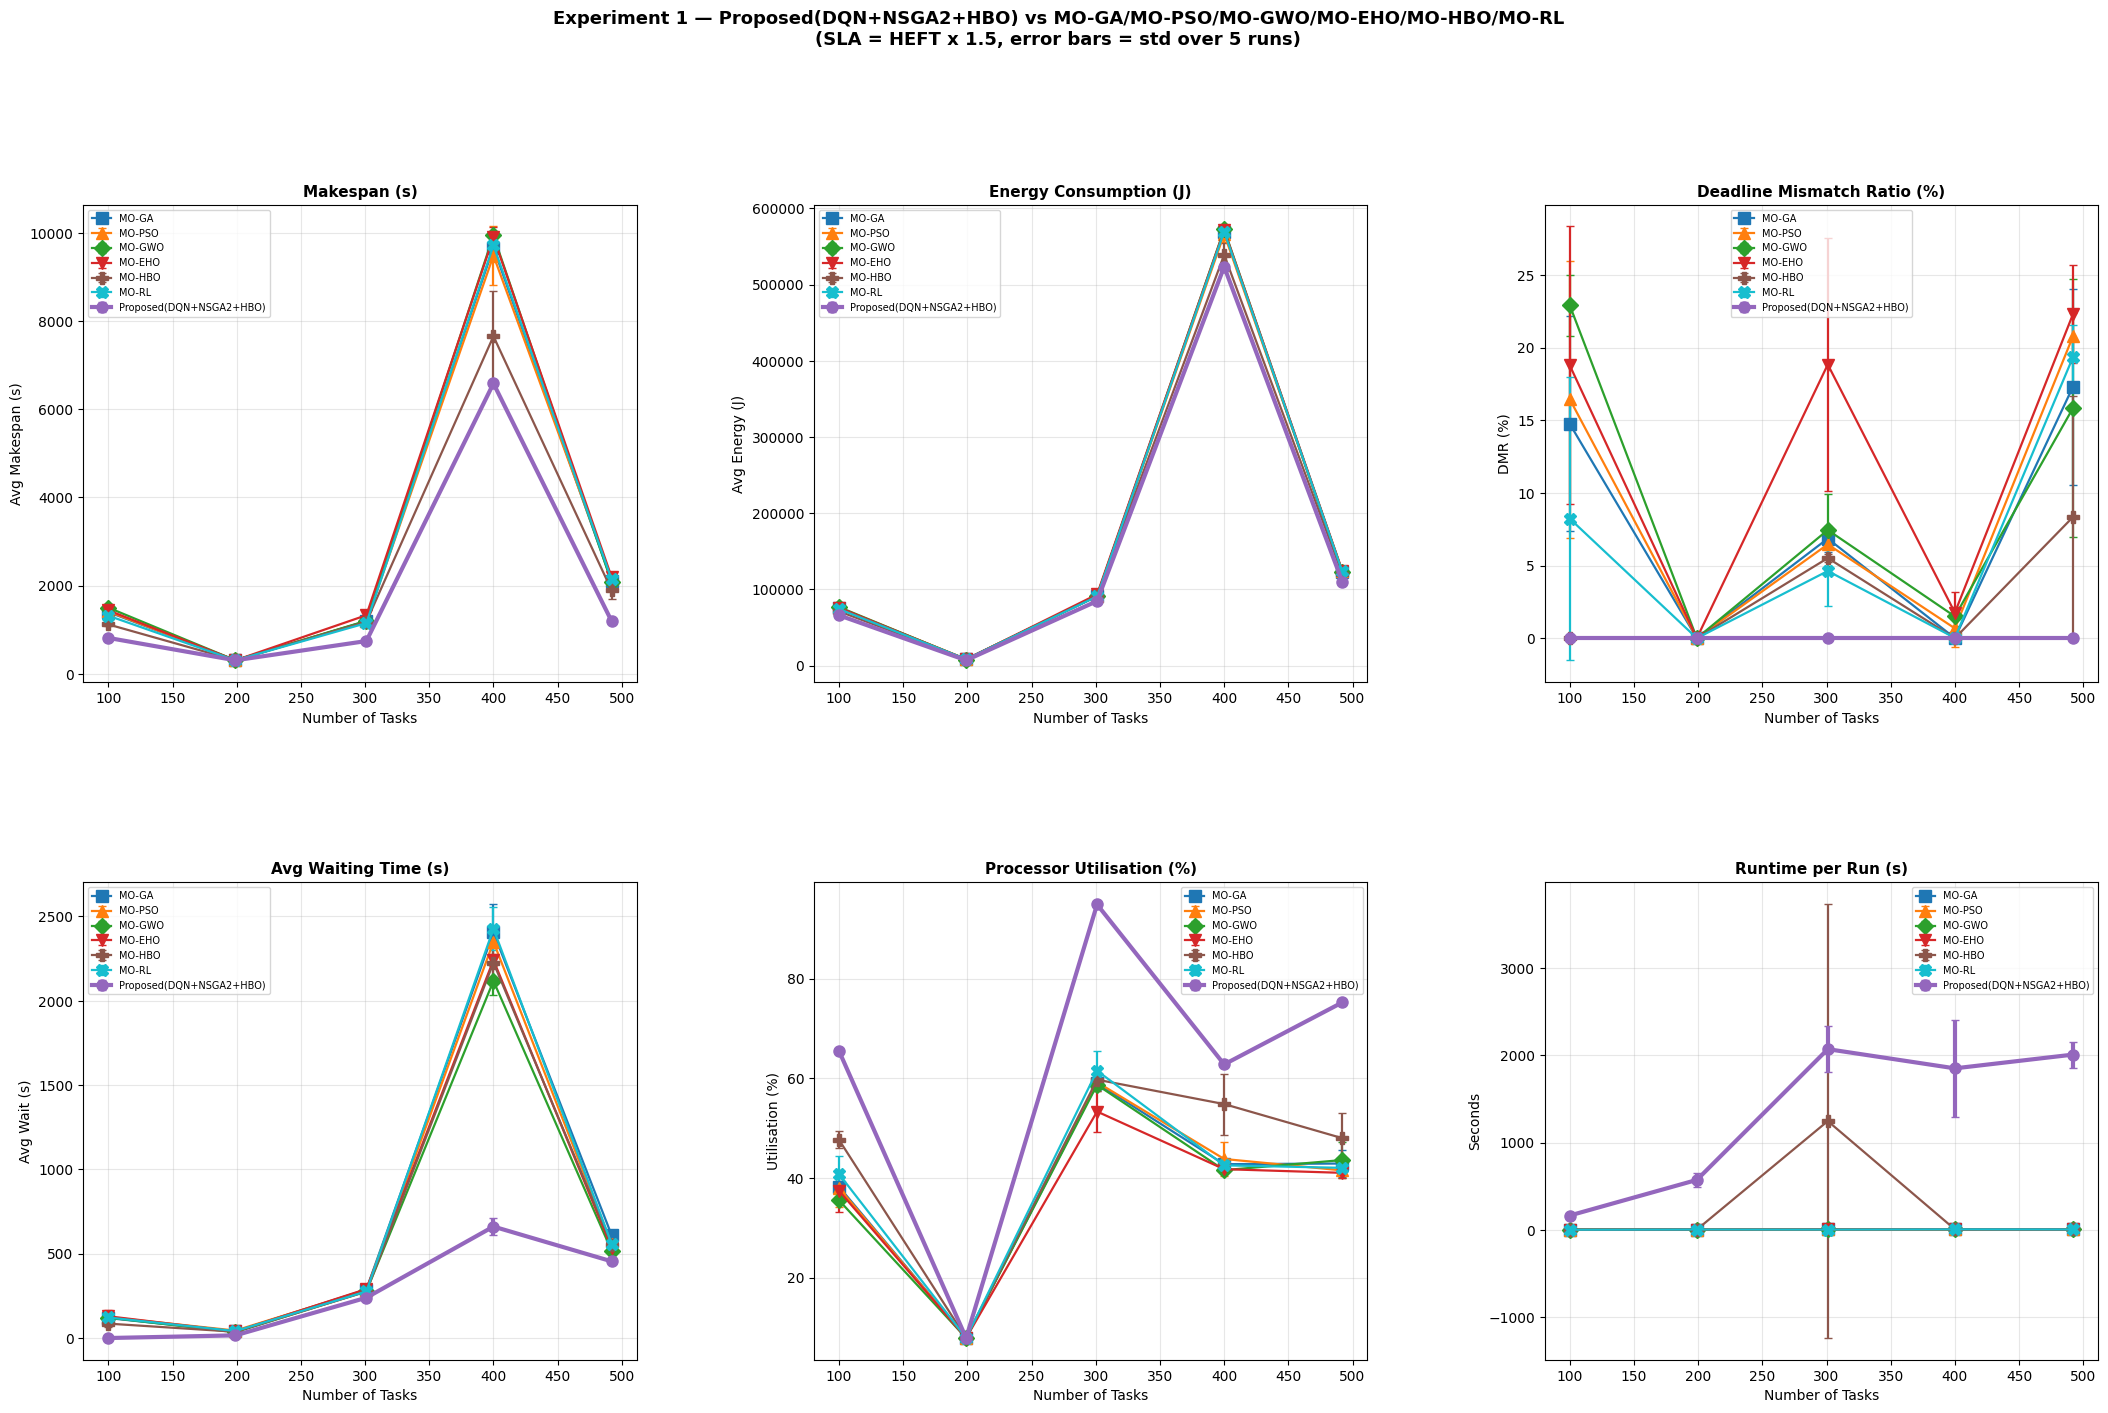

Saved: exp1_scalability.png


In [7]:
# ==========================================
# CELL 6: EXPERIMENT 1 — SCALABILITY (MO baselines vs Proposed)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, time
warnings.filterwarnings("ignore")

NUM_RUNS  = 5
MAX_ITER  = 150
POP_SIZE  = 50
N_OBJ     = 3
ALG_LABEL = "Proposed(DQN+NSGA2+HBO)"
algorithms = ["MO-GA", "MO-PSO", "MO-GWO", "MO-EHO", "MO-HBO", "MO-RL", ALG_LABEL]

print("="*70)
print("EXPERIMENT 1: SCALABILITY BENCHMARK (MO baselines)")
print(f"  Runs={NUM_RUNS} | MaxIter={MAX_ITER} | Pop={POP_SIZE} | Obj={N_OBJ}")
print("="*70)

task_cols  = ['task_name','instance_num','job_name','task_type',
              'status','start_time','end_time','plan_cpu','plan_mem']
df_tasks   = pd.read_csv(preprocessor.batch_task_path, header=None, names=task_cols)
job_counts = df_tasks['job_name'].value_counts()

target_sizes = [100, 200, 300, 400, 500]
selected_jobs, actual_tasks = [], []
for sz in target_sizes:
    job = (job_counts-sz).abs().idxmin()
    selected_jobs.append(job); actual_tasks.append(int(job_counts[job]))

my_processors, _ = preprocessor.load_processors(sample_size=100)
environment = MultiprocessorEnvironment(my_processors, sla_multiplier=1.5)

metrics = ['makespan','energy','wait','util','dmr','runtime']
res     = {a: {m: [] for m in metrics} for a in algorithms}
res_std = {a: {m: [] for m in metrics} for a in algorithms}

for job_id, t_count in zip(selected_jobs, actual_tasks):
    my_dag = preprocessor.load_job_dag(job_id)
    sla    = environment.compute_sla(my_dag)
    heft_m = sla / environment.sla_multiplier

    print(f"\n{'-'*70}")
    print(f"  Job={job_id} | Tasks={t_count}")
    print(f"  HEFT makespan={heft_m:.1f}s | SLA={sla:.1f}s (HEFT x 1.5)")
    print(f"{'-'*70}")

    for algo in algorithms:
        mk_r,en_r,wt_r,ut_r,dmr_r,rt_r=[],[],[],[],[],[]
        print(f"  {algo:<35}", end="", flush=True)
        for _ in range(NUM_RUNS):
            t0=time.time()
            if algo==ALG_LABEL:
                opt    = ProposedOptimizer(environment, my_dag,
                                           pop_size=POP_SIZE, max_iter=MAX_ITER,
                                           n_objectives=N_OBJ)
                result = opt.optimize()
                m,e,awt,util = result[1],result[2],result[3],result[4]
            else:
                algo_clean = algo.replace("MO-", "")
                opt = MOMetaheuristicOptimizer(environment, my_dag,
                                               pop_size=POP_SIZE, max_iter=MAX_ITER,
                                               algo_type=algo_clean, n_objectives=N_OBJ)
                result = opt.optimize()
                m,e,awt,util = result[1],result[2],result[3],result[4]
            rt  = time.time()-t0
            dmr = max(0.0, m-sla)/sla*100
            mk_r.append(m); en_r.append(e); wt_r.append(awt)
            ut_r.append(util); dmr_r.append(dmr); rt_r.append(rt)
            print(".", end="", flush=True)

        for lst,key in [(mk_r,'makespan'),(en_r,'energy'),(wt_r,'wait'),
                        (ut_r,'util'),(dmr_r,'dmr'),(rt_r,'runtime')]:
            res[algo][key].append(np.mean(lst))
            res_std[algo][key].append(np.std(lst))

        status = "BEATS SLA" if np.mean(mk_r) <= sla else "EXCEEDS SLA"
        print(f"  Makespan={np.mean(mk_r):.1f}+/-{np.std(mk_r):.1f}s"
              f" | {status} | DMR={np.mean(dmr_r):.1f}%"
              f" | Energy={np.mean(en_r):.0f}J | Util={np.mean(ut_r)*100:.1f}%")

colors  = {'MO-GA':'#1f77b4','MO-PSO':'#ff7f0e','MO-GWO':'#2ca02c',
           'MO-EHO':'#d62728','MO-HBO':'#8c564b','MO-RL':'#17becf',
           ALG_LABEL:'#9467bd'}
markers = {'MO-GA':'s','MO-PSO':'^','MO-GWO':'D','MO-EHO':'v',
           'MO-HBO':'P','MO-RL':'X', ALG_LABEL:'o'}

fig = plt.figure(figsize=(26,15))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.42,wspace=0.32)
axes= [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(3)]

panels = [
    ('makespan','Makespan (s)',              'Avg Makespan (s)'),
    ('energy',  'Energy Consumption (J)',    'Avg Energy (J)'),
    ('dmr',     'Deadline Mismatch Ratio (%)','DMR (%)'),
    ('wait',    'Avg Waiting Time (s)',       'Avg Wait (s)'),
    ('util',    'Processor Utilisation (%)',  'Utilisation (%)'),
    ('runtime', 'Runtime per Run (s)',        'Seconds'),
]
for ax,(key,title,ylabel) in zip(axes,panels):
    for a in algorithms:
        vals  = res[a][key]; stds = res_std[a][key]
        yvals = [v*100 if key=='util' else v for v in vals]
        yerr  = [s*100 if key=='util' else s for s in stds]
        lw    = 3 if a==ALG_LABEL else 1.6
        ax.errorbar(actual_tasks, yvals, yerr=yerr,
                    label=a, color=colors[a], marker=markers[a],
                    linewidth=lw, markersize=8, capsize=3,
                    zorder=3 if a==ALG_LABEL else 2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Number of Tasks', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

plt.suptitle(f'Experiment 1 — {ALG_LABEL} vs MO-GA/MO-PSO/MO-GWO/MO-EHO/MO-HBO/MO-RL\n'
             f'(SLA = HEFT x 1.5, error bars = std over {NUM_RUNS} runs)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('exp1_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exp1_scalability.png")

In [8]:
# ==========================================
# CELL 6-PREP: minimal setup for Cell 7
# (skips the long Experiment 1 loop)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ALG_LABEL = "Proposed(DQN+NSGA2+HBO)"

task_cols  = ['task_name','instance_num','job_name','task_type',
              'status','start_time','end_time','plan_cpu','plan_mem']
df_tasks   = pd.read_csv(preprocessor.batch_task_path, header=None, names=task_cols)
job_counts = df_tasks['job_name'].value_counts()

target_sizes = [100, 200, 300, 400, 500]
selected_jobs, actual_tasks = [], []
for sz in target_sizes:
    job = (job_counts-sz).abs().idxmin()
    selected_jobs.append(job)
    actual_tasks.append(int(job_counts[job]))

my_processors, _ = preprocessor.load_processors(sample_size=100)
environment = MultiprocessorEnvironment(my_processors, sla_multiplier=1.5)

print(f"selected_jobs = {selected_jobs}")
print(f"environment   = {environment}")
print("Ready for Cell 7.")

2026-05-04 05:15:25,699 - INFO - Loading processor metadata...
2026-05-04 05:15:25,737 - INFO - Generated 100 Processors.


selected_jobs = ['j_2926852', 'j_1787378', 'j_139493', 'j_3166034', 'j_652317']
environment   = <__main__.MultiprocessorEnvironment object at 0x000002F581B47ED0>
Ready for Cell 7.



EXPERIMENT 1 — TABULAR SUMMARY

--- MAKESPAN (s, mean ± std over 5 runs) ---
    Algorithm    100 tasks 199 tasks   301 tasks     400 tasks    492 tasks
        MO-GA  1400.2±91.4 305.8±0.0 1194.5±10.0  9668.1±102.0 2105.1±121.1
       MO-PSO 1415.6±126.8 306.1±0.1 1190.1±10.7  9487.5±660.4  2167.4±28.3
       MO-GWO  1500.4±25.8 306.1±0.2 1201.1±27.5   9944.9±66.2 2077.4±161.6
       MO-EHO 1439.0±138.3 306.1±0.1 1328.4±97.6  9903.7±224.3  2194.7±60.2
       MO-HBO  1119.7±39.9 306.0±0.1  1179.5±3.1 7656.4±1028.3 1896.7±201.9
        MO-RL 1317.4±122.3 306.1±0.1 1149.4±66.7   9720.4±49.5  2141.5±39.9
DQN+NSGA2+HBO    813.8±0.0 305.8±0.0   742.6±0.5    6585.6±5.4   1196.3±0.0

--- ENERGY (J) ---
    Algorithm 100 tasks 199 tasks 301 tasks 400 tasks 492 tasks
        MO-GA     75556      8148     91490    569476    123157
       MO-PSO     75716      8670     91424    566480    124103
       MO-GWO     76960      8102     91586    572354    122798
       MO-EHO     76119      8214     

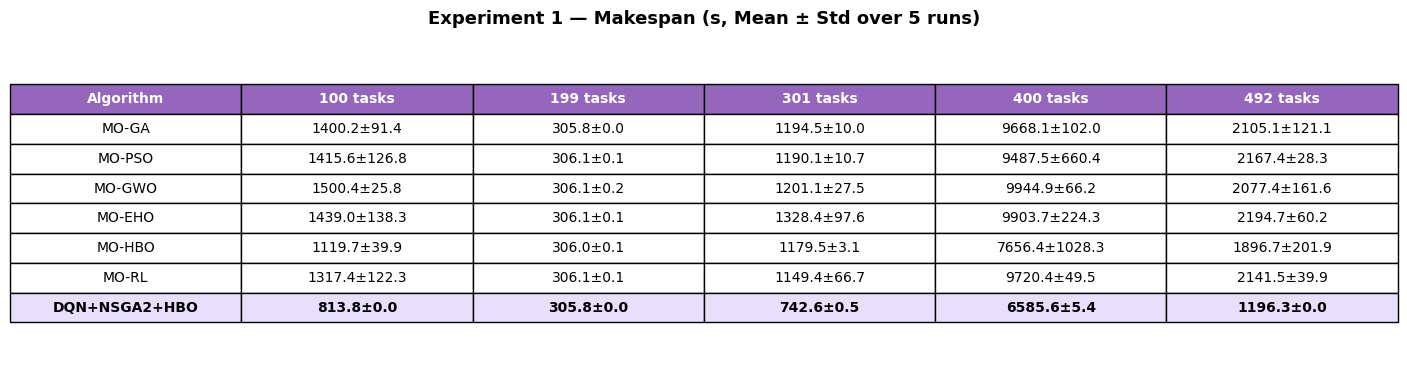

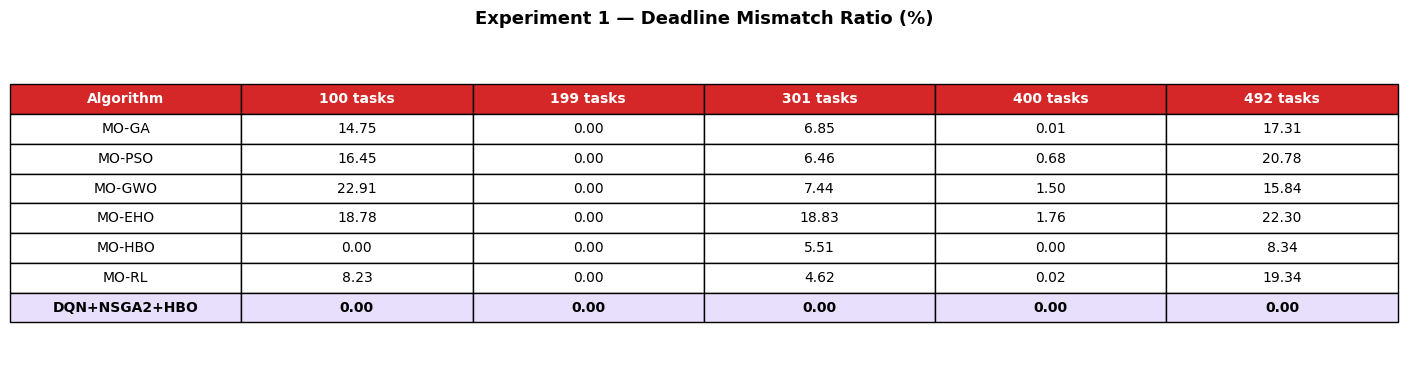

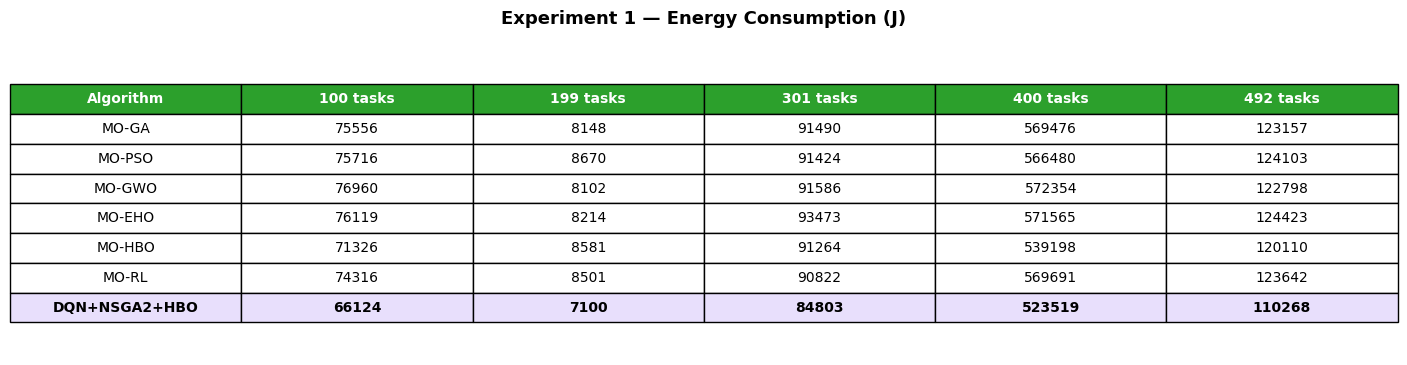


Saved: exp1_table_makespan.png, exp1_table_dmr.png, exp1_table_energy.png


In [9]:
# ==========================================
# CELL 6B: TABULAR SUMMARY OF EXPERIMENT 1
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("EXPERIMENT 1 — TABULAR SUMMARY")
print("=" * 100)

def _build_table(metric_key, with_std=False, mult=1.0, fmt="{:.2f}"):
    rows = []
    for a in algorithms:
        clean_name = a.replace("Proposed(", "").replace(")", "")
        row = {'Algorithm': clean_name}
        for i, sz in enumerate(actual_tasks):
            mean = res[a][metric_key][i] * mult
            if with_std:
                std = res_std[a][metric_key][i] * mult
                row[f'{sz} tasks'] = f"{mean:.1f}±{std:.1f}"
            else:
                row[f'{sz} tasks'] = fmt.format(mean)
        rows.append(row)
    return pd.DataFrame(rows)

print("\n--- MAKESPAN (s, mean ± std over 5 runs) ---")
df_mk = _build_table('makespan', with_std=True)
print(df_mk.to_string(index=False))

print("\n--- ENERGY (J) ---")
df_en = _build_table('energy', fmt="{:.0f}")
print(df_en.to_string(index=False))

print("\n--- DMR (%) — Deadline Mismatch Ratio ---")
df_dmr = _build_table('dmr', fmt="{:.2f}")
print(df_dmr.to_string(index=False))

print("\n--- UTILIZATION (%) ---")
df_ut = _build_table('util', mult=100, fmt="{:.1f}")
print(df_ut.to_string(index=False))

print("\n--- RUNTIME (s per run) ---")
df_rt = _build_table('runtime', fmt="{:.1f}")
print(df_rt.to_string(index=False))

def _render_table_png(df, title, filename, color='#9467bd'):
    fig, ax = plt.subplots(figsize=(14, 0.6 + 0.45*len(df)))
    ax.axis('off')
    table_data = df.values.tolist()
    headers    = list(df.columns)
    t = ax.table(cellText=table_data, colLabels=headers,
                 loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(10)
    t.scale(1.1, 1.7)
    for j in range(len(headers)):
        t[0, j].set_facecolor(color)
        t[0, j].set_text_props(color='white', fontweight='bold')
    proposed_row = len(df)
    for j in range(len(headers)):
        t[proposed_row, j].set_facecolor('#e8dffc')
        t[proposed_row, j].set_text_props(fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=20)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

_render_table_png(df_mk, 'Experiment 1 — Makespan (s, Mean ± Std over 5 runs)',
                  'exp1_table_makespan.png')
_render_table_png(df_dmr, 'Experiment 1 — Deadline Mismatch Ratio (%)',
                  'exp1_table_dmr.png', color='#d62728')
_render_table_png(df_en, 'Experiment 1 — Energy Consumption (J)',
                  'exp1_table_energy.png', color='#2ca02c')

print("\nSaved: exp1_table_makespan.png, exp1_table_dmr.png, exp1_table_energy.png")

2026-05-04 05:15:27,101 - INFO - Extracting DAG for Job: j_3166034


Running Multi-Objective Configurations...
  2-Obj (Makespan+Energy) ... Done | Makespan=6532.2s | Pareto solutions=50
  3-Obj (Makespan+Energy+Wait) ... Done | Makespan=6583.3s | Pareto solutions=9
  4-Obj (Makespan+Energy+Wait+Util) ... Done | Makespan=6591.7s | Pareto solutions=13


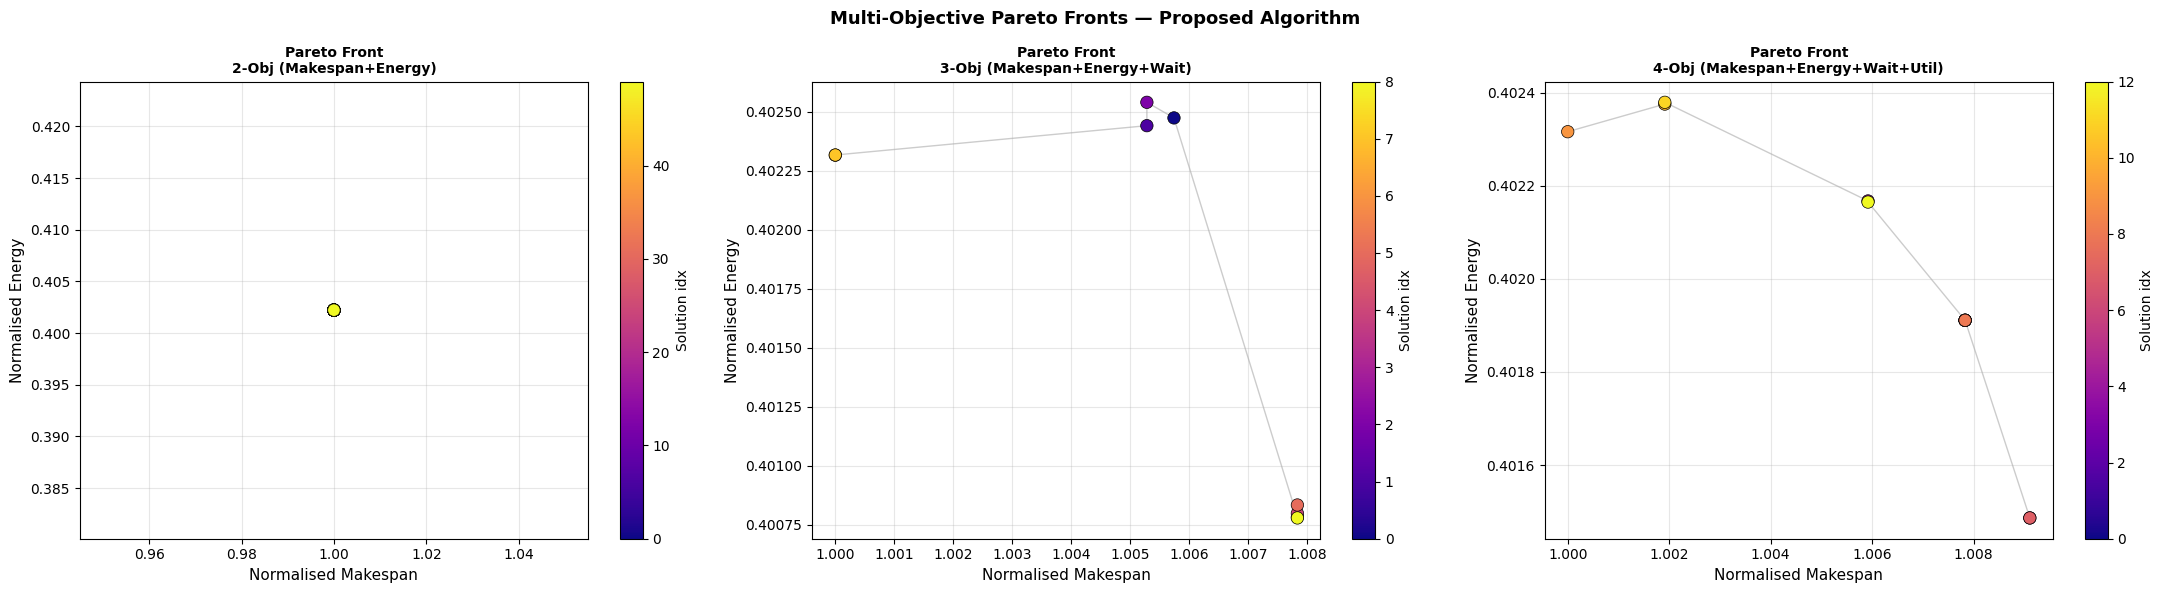

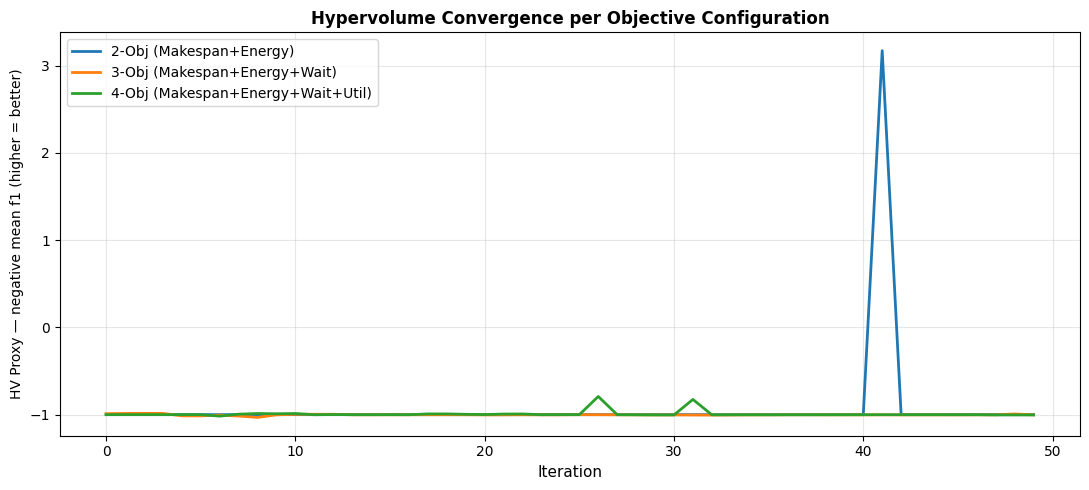

Saved: exp2_pareto_fronts.png, exp2_hv_convergence.png


In [10]:
# ==========================================
# CELL 7: MULTI-OBJECTIVE PARETO ANALYSIS
# ==========================================
import matplotlib.pyplot as plt

target_job = selected_jobs[3]   # 400-task job for visible Pareto trade-offs
mo_dag     = preprocessor.load_job_dag(target_job)
sla        = environment.compute_sla(mo_dag)

obj_configs = {
    "2-Obj (Makespan+Energy)":           2,
    "3-Obj (Makespan+Energy+Wait)":      3,
    "4-Obj (Makespan+Energy+Wait+Util)": 4,
}

mo_results = {}
print("Running Multi-Objective Configurations...")
for label, n_obj in obj_configs.items():
    print(f"  {label} ...", end="", flush=True)
    opt    = ProposedOptimizer(environment, mo_dag,
                               pop_size=50, max_iter=50, n_objectives=n_obj)
    result = opt.optimize()
    mo_results[label] = dict(
        pf_objs    = result[6],
        hv_history = result[7],
        best_m     = result[1],
        best_e     = result[2],
        best_wait  = result[3],
        best_util  = result[4],
        n_obj      = n_obj,
    )
    print(f" Done | Makespan={result[1]:.1f}s | Pareto solutions={len(result[6])}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (label, data) in zip(axes, mo_results.items()):
    pf = data['pf_objs']
    if not pf:
        ax.set_title(f'{label}\n(no solutions)'); continue
    xs = [o[0] for o in pf]; ys = [o[1] for o in pf]
    order = np.argsort(xs)
    xs_s  = np.array(xs)[order]; ys_s = np.array(ys)[order]
    ax.plot(xs_s, ys_s, '-', color='#cccccc', linewidth=1, zorder=1)
    sc = ax.scatter(xs, ys, c=range(len(pf)), cmap='plasma',
                    s=80, zorder=5, edgecolors='k', linewidths=0.5)
    ax.set_xlabel('Normalised Makespan', fontsize=11)
    ax.set_ylabel('Normalised Energy',   fontsize=11)
    ax.set_title(f'Pareto Front\n{label}', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Solution idx')

plt.suptitle('Multi-Objective Pareto Fronts — Proposed Algorithm',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp2_pareto_fronts.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for label, data in mo_results.items():
    ax.plot(data['hv_history'], label=label, linewidth=2)
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('HV Proxy — negative mean f1 (higher = better)', fontsize=10)
ax.set_title('Hypervolume Convergence per Objective Configuration',
             fontweight='bold', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp2_hv_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exp2_pareto_fronts.png, exp2_hv_convergence.png")

2026-05-04 05:44:06,229 - INFO - Extracting DAG for Job: j_139493


Statistical validation — 30 runs, job=j_139493, SLA=1117.9s
  Testing MO-GA...  Mean=1197.2 ± 10.6s
  Testing MO-PSO...  Mean=1200.5 ± 39.3s
  Testing MO-GWO...  Mean=1187.3 ± 67.2s
  Testing MO-EHO...  Mean=1229.4 ± 72.3s
  Testing MO-HBO...  Mean=1138.1 ± 78.8s
  Testing MO-RL...  Mean=1142.1 ± 72.7s
  Testing Proposed(DQN+NSGA2+HBO)...  Mean=742.5 ± 0.5s

--- Mean ± Std Makespan ---
  Algorithm                             Mean (s)    Std (s)
  ---------------------------------------------------------
  MO-GA                                  1197.24      10.59
  MO-PSO                                 1200.51      39.34
  MO-GWO                                 1187.31      67.18
  MO-EHO                                 1229.37      72.34
  MO-HBO                                 1138.10      78.83
  MO-RL                                  1142.10      72.74
  Proposed(DQN+NSGA2+HBO)                 742.50       0.47

--- Wilcoxon Rank-Sum (Proposed(DQN+NSGA2+HBO) vs others) ---
  vs MO-

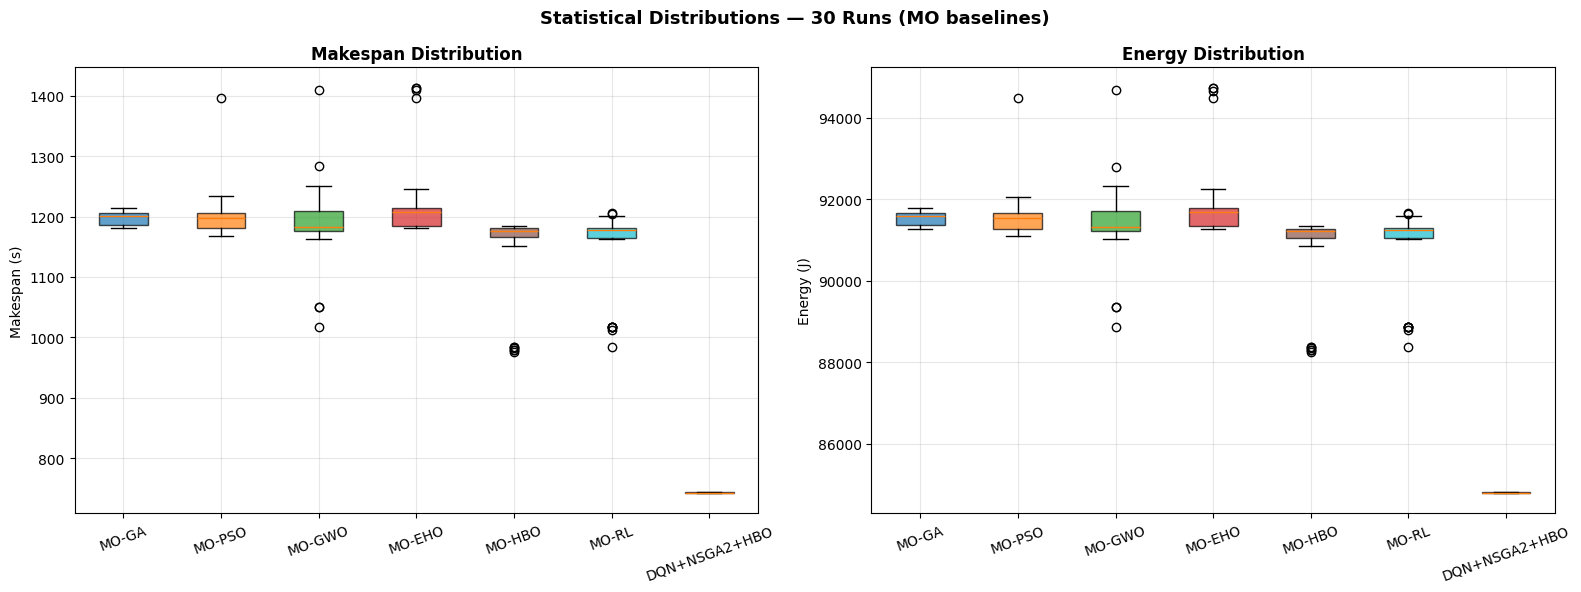

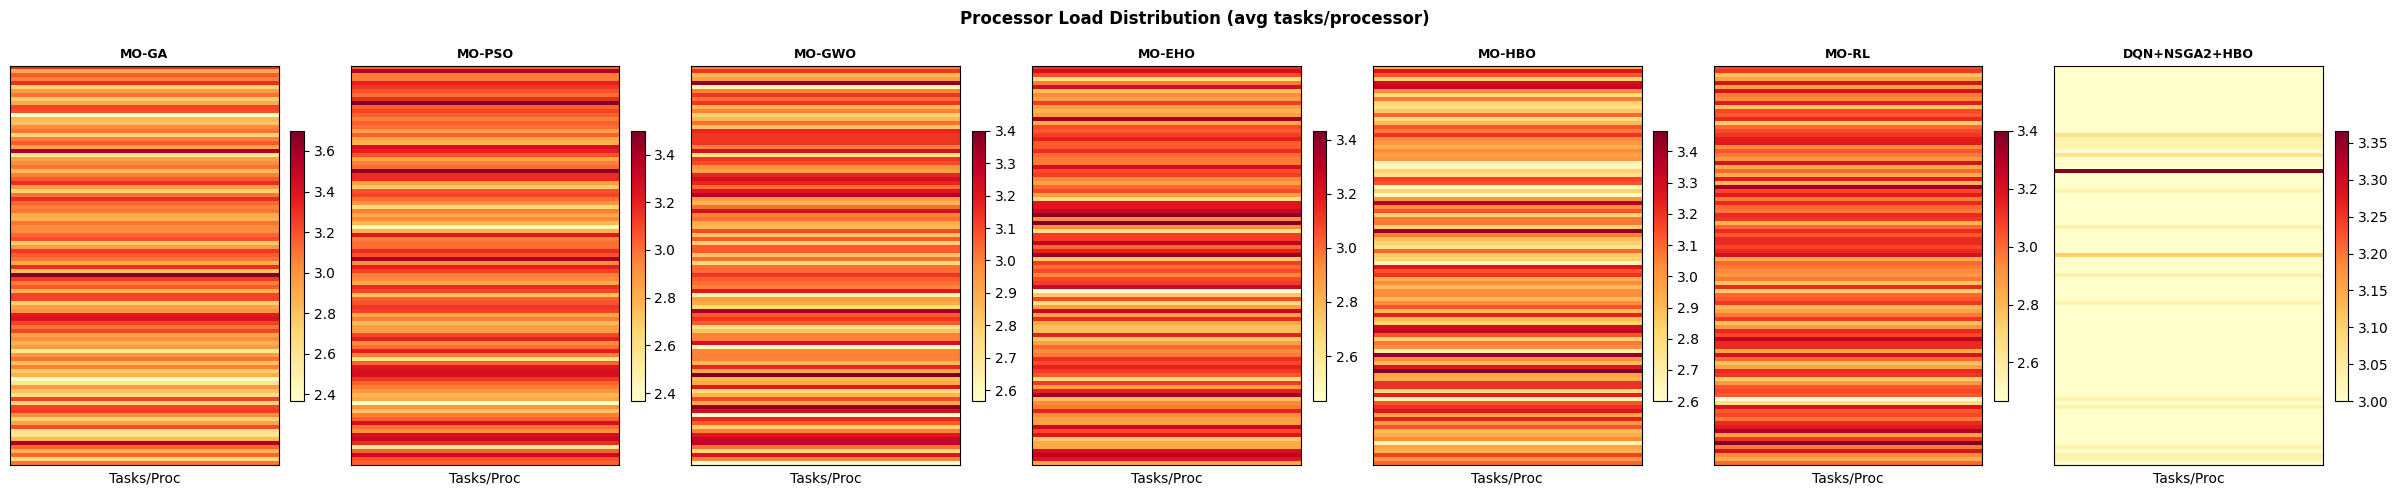

Saved: exp3_boxplots.png, exp3_heatmap.png


In [11]:
# ==========================================
# CELL 8: STATISTICAL VALIDATION (MO baselines)
# ==========================================
from scipy.stats import ranksums, friedmanchisquare
import matplotlib.pyplot as plt

STATS_RUNS = 30
target_job = selected_jobs[2]
stat_dag   = preprocessor.load_job_dag(target_job)
sla        = environment.compute_sla(stat_dag)

stat_algos  = ["MO-GA", "MO-PSO", "MO-GWO", "MO-EHO", "MO-HBO", "MO-RL", ALG_LABEL]
stats_m     = {a: [] for a in stat_algos}
stats_e     = {a: [] for a in stat_algos}
stats_loads = {a: [] for a in stat_algos}

print(f"Statistical validation — {STATS_RUNS} runs, job={target_job}, SLA={sla:.1f}s")
for algo in stat_algos:
    print(f"  Testing {algo}...", end="", flush=True)
    for _ in range(STATS_RUNS):
        if algo == ALG_LABEL:
            opt    = ProposedOptimizer(environment, stat_dag,
                                       pop_size=POP_SIZE, max_iter=MAX_ITER,
                                       n_objectives=N_OBJ)
            result = opt.optimize()
            m, e   = result[1], result[2]
            loads  = result[8]
        else:
            algo_clean = algo.replace("MO-", "")
            opt = MOMetaheuristicOptimizer(environment, stat_dag,
                                           pop_size=POP_SIZE, max_iter=MAX_ITER,
                                           algo_type=algo_clean, n_objectives=N_OBJ)
            result = opt.optimize()
            m, e   = result[1], result[2]
            loads  = result[8]
        stats_m[algo].append(m)
        stats_e[algo].append(e)
        if loads: stats_loads[algo].append(list(loads.values()))
    mu = np.mean(stats_m[algo]); sd = np.std(stats_m[algo])
    print(f"  Mean={mu:.1f} ± {sd:.1f}s")

print("\n--- Mean ± Std Makespan ---")
print(f"  {'Algorithm':<35} {'Mean (s)':>10} {'Std (s)':>10}")
print("  " + "-"*57)
for a in stat_algos:
    print(f"  {a:<35} {np.mean(stats_m[a]):>10.2f} {np.std(stats_m[a]):>10.2f}")

print(f"\n--- Wilcoxon Rank-Sum ({ALG_LABEL} vs others) ---")
for a in ["MO-GA","MO-PSO","MO-GWO","MO-EHO","MO-HBO","MO-RL"]:
    stat, p = ranksums(stats_m[a], stats_m[ALG_LABEL])
    h_mean  = np.mean(stats_m[ALG_LABEL])
    o_mean  = np.mean(stats_m[a])
    imp     = (o_mean - h_mean) / o_mean * 100
    verdict = "WINS" if h_mean < o_mean else "loses"
    print(f"  vs {a:<7}: p={p:.5f} | delta={imp:+.1f}%  {verdict}")

print("\n--- Friedman Test ---")
min_len = min(len(stats_m[a]) for a in stat_algos)
fstat, fp = friedmanchisquare(*[stats_m[a][:min_len] for a in stat_algos])
print(f"  Statistic={fstat:.3f}, p={fp:.5f}")
print("  -> Significant (p<0.05)" if fp < 0.05 else "  -> Not significant")

clrs = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#8c564b','#17becf','#9467bd']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data_dict, title, ylabel in [
    (axes[0], stats_m, 'Makespan Distribution', 'Makespan (s)'),
    (axes[1], stats_e, 'Energy Distribution',   'Energy (J)'),
]:
    bp = ax.boxplot([data_dict[a] for a in stat_algos],
                    patch_artist=True, notch=False,
                    labels=[a.replace('Proposed(','').replace(')','')
                            for a in stat_algos])
    for patch, c in zip(bp['boxes'], clrs):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(f'Statistical Distributions — {STATS_RUNS} Runs (MO baselines)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, len(stat_algos), figsize=(24, 5))
for ax, algo in zip(axes, stat_algos):
    if stats_loads[algo]:
        matrix   = np.array(stats_loads[algo])
        avg_load = matrix.mean(axis=0).reshape(-1, 1)
    else:
        avg_load = (np.random.dirichlet(np.ones(len(my_processors)))
                    * len(stat_dag)).reshape(-1, 1)
    im = ax.imshow(avg_load, aspect='auto', cmap='YlOrRd',
                   interpolation='nearest')
    short = algo.replace('Proposed(','').replace(')','')
    ax.set_title(short, fontsize=9, fontweight='bold')
    ax.set_xlabel('Tasks/Proc'); ax.set_yticks([]); ax.set_xticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Processor Load Distribution (avg tasks/processor)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('exp3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exp3_boxplots.png, exp3_heatmap.png")

BENCHMARK 1: ZDT Suite (6 functions, 2-objective)
  ZDT1: Pareto solutions=50   Mean f1=0.4151 +/- 0.2981  Spread=0.5740
  ZDT2: Pareto solutions=50   Mean f1=0.6204 +/- 0.2652  Spread=0.5695
  ZDT3: Pareto solutions=50   Mean f1=0.4194 +/- 0.2821  Spread=0.8049
  ZDT4: Pareto solutions=7    Mean f1=0.1983 +/- 0.1384  Spread=0.4890
  ZDT5: Pareto solutions=50   Mean f1=6.5000 +/- 3.5567  Spread=5.9796
  ZDT6: Pareto solutions=12   Mean f1=0.3975 +/- 0.2024  Spread=0.9847

BENCHMARK 2: DTLZ Suite (7 functions, 2-4 objectives)
  DTLZ1_2obj      : sols=50  Mean f1=0.2362 +/- 0.1524
  DTLZ2_2obj      : sols=50  Mean f1=0.6169 +/- 0.3127
  DTLZ3_2obj      : sols=50  Mean f1=0.6529 +/- 0.3048
  DTLZ4_2obj      : sols=1   Mean f1=1.0003 +/- 0.0000
  DTLZ5_2obj      : sols=50  Mean f1=0.6195 +/- 0.3138
  DTLZ6_2obj      : sols=6   Mean f1=1.5869 +/- 1.2199
  DTLZ7_2obj      : sols=50  Mean f1=0.5308 +/- 0.2912
  DTLZ1_3obj      : sols=50  Mean f1=0.1597 +/- 0.1533
  DTLZ2_3obj      : sols=50  

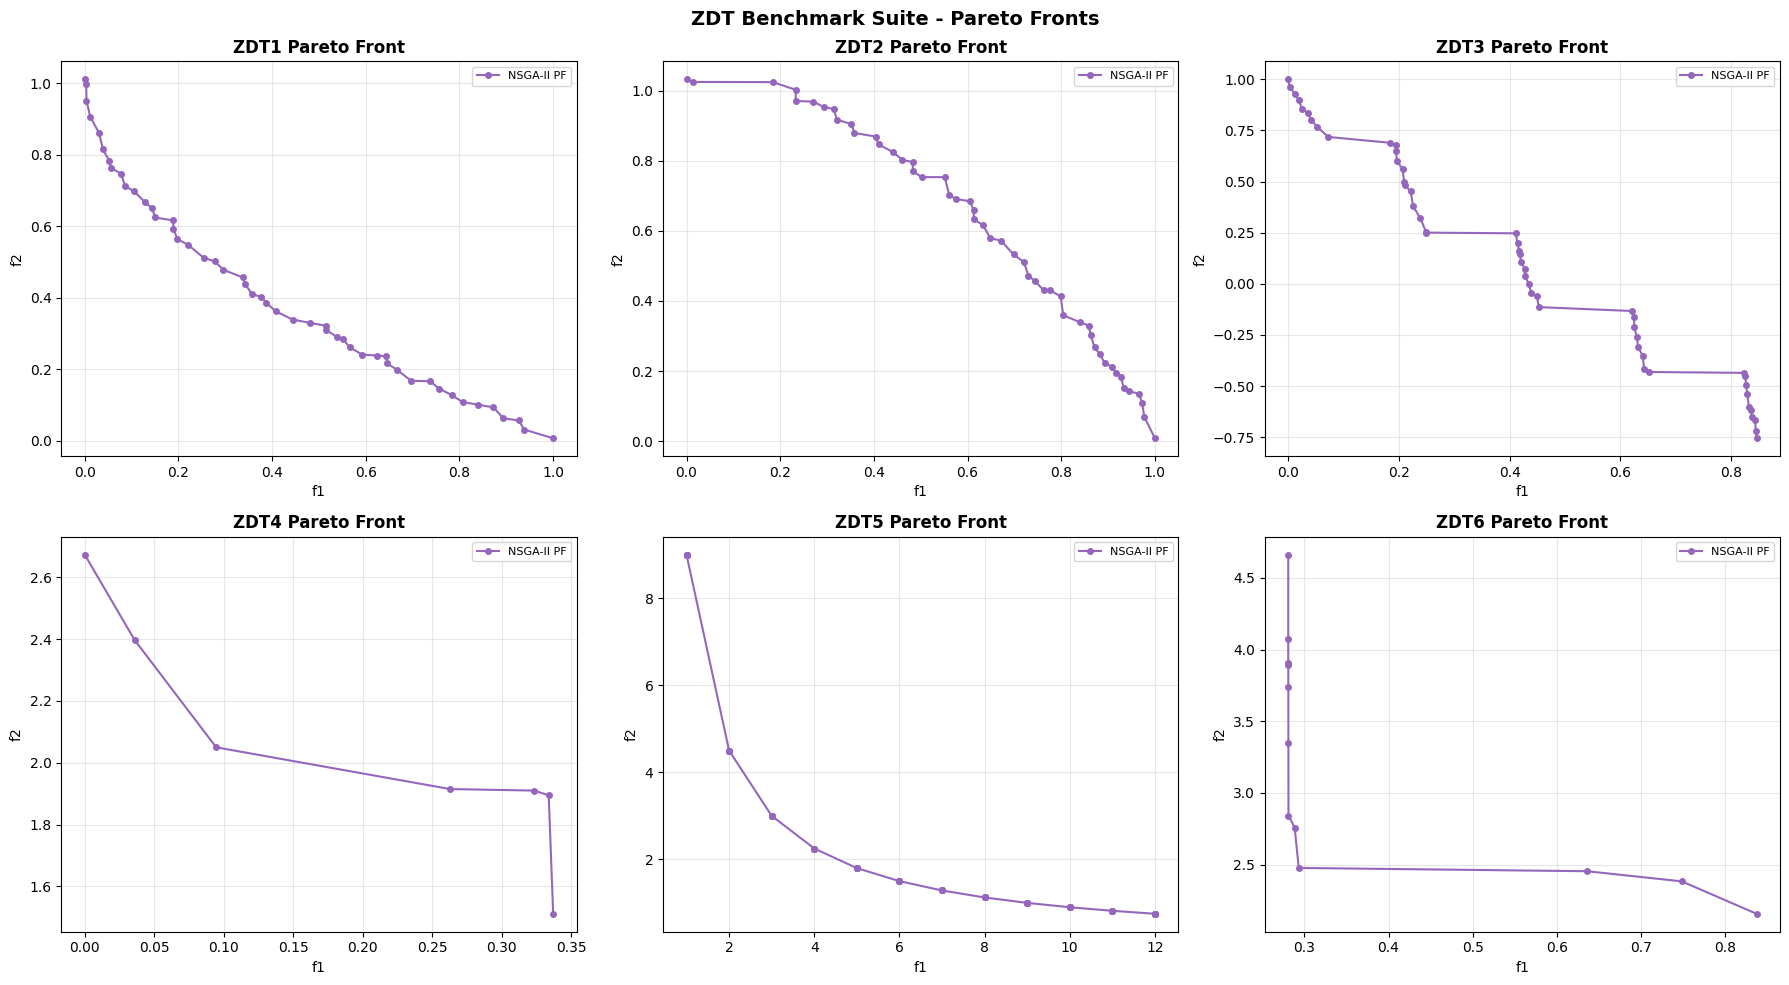

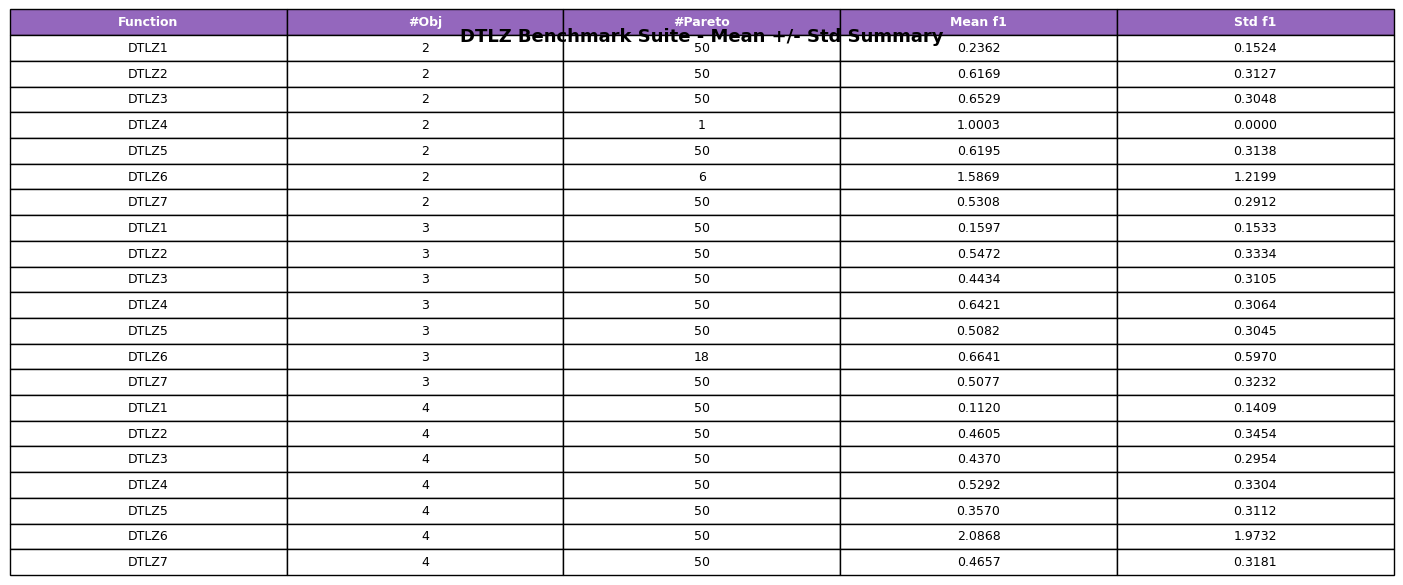


Saved: benchmark_zdt.png, benchmark_dtlz_table.png

ALL EXPERIMENTS COMPLETE


In [12]:
# ==========================================
# CELL 9: BENCHMARK VALIDATION — ZDT (6) + DTLZ (7, up to 4-obj)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ranksums

def zdt1(x):
    f1 = x[0]
    g  = 1 + 9*np.mean(x[1:])
    f2 = g * (1 - np.sqrt(f1/g))
    return f1, f2

def zdt2(x):
    f1 = x[0]
    g  = 1 + 9*np.mean(x[1:])
    f2 = g * (1 - (f1/g)**2)
    return f1, f2

def zdt3(x):
    f1 = x[0]
    g  = 1 + 9*np.mean(x[1:])
    f2 = g * (1 - np.sqrt(f1/g) - (f1/g)*np.sin(10*np.pi*f1))
    return f1, f2

def zdt4(x):
    n  = len(x)
    f1 = x[0]
    g  = 1 + 10*(n-1) + np.sum(x[1:]**2 - 10*np.cos(4*np.pi*x[1:]))
    f2 = g * (1 - np.sqrt(f1/g))
    return f1, f2

def zdt5(x):
    u1 = int(round(float(np.clip(x[0], 0, 1)) * 11))
    f1 = float(1 + u1)
    vs = []
    for xi in x[1:]:
        ui = int(round(float(np.clip(xi, 0, 1)) * 5))
        vs.append(1 if ui >= 5 else 2 + ui)
    g  = float(sum(vs))
    f2 = g / f1
    return f1, f2

def zdt6(x):
    f1 = 1 - np.exp(-4*x[0]) * np.sin(6*np.pi*x[0])**6
    g  = 1 + 9*(np.mean(x[1:])**0.25)
    f2 = g * (1 - (f1/g)**2)
    return f1, f2

ZDT_FUNCS = {'ZDT1':zdt1,'ZDT2':zdt2,'ZDT3':zdt3,
             'ZDT4':zdt4,'ZDT5':zdt5,'ZDT6':zdt6}

def dtlz1(x, M=3):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = 100*(k + np.sum((xm-0.5)**2 - np.cos(20*np.pi*(xm-0.5))))
    objs = []
    for i in range(M):
        f = 0.5*(1+g)
        for j in range(M-1-i): f *= x[j]
        if i > 0: f *= (1 - x[M-1-i])
        objs.append(f)
    return objs

def dtlz2(x, M=3):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = np.sum((xm - 0.5)**2)
    objs = []
    for i in range(M):
        f = (1+g)
        for j in range(M-1-i): f *= np.cos(x[j]*np.pi/2)
        if i > 0: f *= np.sin(x[M-1-i]*np.pi/2)
        objs.append(f)
    return objs

def dtlz3(x, M=3):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = 100*(k + np.sum((xm-0.5)**2 - np.cos(20*np.pi*(xm-0.5))))
    objs = []
    for i in range(M):
        f = (1+g)
        for j in range(M-1-i): f *= np.cos(x[j]*np.pi/2)
        if i > 0: f *= np.sin(x[M-1-i]*np.pi/2)
        objs.append(f)
    return objs

def dtlz4(x, M=3, alpha=100):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = np.sum((xm - 0.5)**2)
    objs = []
    for i in range(M):
        f = (1+g)
        for j in range(M-1-i): f *= np.cos((x[j]**alpha)*np.pi/2)
        if i > 0: f *= np.sin((x[M-1-i]**alpha)*np.pi/2)
        objs.append(f)
    return objs

def dtlz5(x, M=3):
    return dtlz2(x, M)

def dtlz6(x, M=3):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = np.sum(xm**0.1)
    objs = []
    for i in range(M):
        f = (1+g)
        for j in range(M-1-i): f *= np.cos(x[j]*np.pi/2)
        if i > 0: f *= np.sin(x[M-1-i]*np.pi/2)
        objs.append(f)
    return objs

def dtlz7(x, M=3):
    k  = len(x) - M + 1
    xm = x[M-1:]
    g  = 1 + 9*np.mean(xm)
    objs = list(x[:M-1])
    h  = M - sum(fi/(1+g)*(1+np.sin(3*np.pi*fi)) for fi in objs)
    objs.append((1+g)*h)
    return objs

DTLZ_FUNCS = {f'DTLZ{i}': fn for i, fn in
              enumerate([dtlz1,dtlz2,dtlz3,dtlz4,dtlz5,dtlz6,dtlz7], 1)}

def run_nsga2_on_func(func, n_var=10, n_obj=2, pop=50, iters=100,
                      biased_init=False, m_for_bias=2):
    population = np.random.rand(pop, n_var)
    if biased_init:
        k = n_var - m_for_bias + 1
        population[:, m_for_bias-1:] = 0.5 + np.random.uniform(-1e-6, 1e-6, (pop, k))

    for _ in range(iters):
        offspring = []
        for i in range(pop):
            p1 = population[np.random.randint(pop)]
            p2 = population[np.random.randint(pop)]
            mask = np.random.rand(n_var) > 0.5
            child = np.where(mask, p1, p2)
            if biased_init:
                noise = np.random.normal(0, 0.02, n_var)
                noise[m_for_bias-1:] = np.random.normal(0, 1e-5, n_var - m_for_bias + 1)
                child = child + noise
            else:
                child += np.random.normal(0, 0.02, n_var)
            offspring.append(np.clip(child, 0, 1))
        offspring = np.array(offspring)
        comb = np.vstack((population, offspring))
        try:
            objs  = [func(comb[i]) if n_obj > 2 else list(func(comb[i]))
                     for i in range(len(comb))]
        except: break
        objs  = [list(o) if hasattr(o,'__iter__') else o for o in objs]
        valid = [(i, o) for i, o in enumerate(objs) if
                 isinstance(o, (list,tuple)) and len(o) == n_obj and
                 all(np.isfinite(v) for v in o)]
        if len(valid) < pop: break
        idx_v, objs_v = zip(*valid)
        fronts = _fast_non_dominated_sort(list(objs_v))
        sel = []
        for fr in fronts:
            if len(sel)+len(fr) <= pop: sel.extend(fr)
            else:
                rem = pop-len(sel)
                cd  = _crowding_distance([objs_v[i] for i in fr])
                top = sorted(range(len(fr)), key=lambda x: cd[x], reverse=True)[:rem]
                sel.extend([fr[t] for t in top])
            if len(sel) >= pop: break
        population = np.array([comb[idx_v[i]] for i in sel[:pop]])
    try:
        final_objs = [list(func(population[i])) if n_obj > 2
                      else list(func(population[i]))
                      for i in range(len(population))]
        valid_final = [o for o in final_objs
                       if isinstance(o,(list,tuple)) and len(o)==n_obj
                       and all(np.isfinite(v) for v in o)]
        fronts = _fast_non_dominated_sort(valid_final)
        return [valid_final[i] for i in fronts[0]]
    except:
        return []

print("=" * 55)
print("BENCHMARK 1: ZDT Suite (6 functions, 2-objective)")
print("=" * 55)
zdt_results = {}
for name, fn in ZDT_FUNCS.items():
    pf = run_nsga2_on_func(fn, n_var=10, n_obj=2, pop=50, iters=80)
    f1s = [o[0] for o in pf]; f2s = [o[1] for o in pf]
    spread = np.std(f1s) + np.std(f2s) if pf else 0
    zdt_results[name] = {'pf': pf, 'n_sols': len(pf),
                         'mean_f1': np.mean(f1s) if f1s else 0,
                         'std_f1':  np.std(f1s)  if f1s else 0,
                         'spread':  spread}
    print(f"  {name}: Pareto solutions={len(pf):<4} "
          f"Mean f1={np.mean(f1s):.4f} +/- {np.std(f1s):.4f}  "
          f"Spread={spread:.4f}")

print("\n" + "=" * 55)
print("BENCHMARK 2: DTLZ Suite (7 functions, 2-4 objectives)")
print("=" * 55)
dtlz_results = {}
for n_obj in [2, 3, 4]:
    for name, fn in DTLZ_FUNCS.items():
        key      = f"{name}_{n_obj}obj"
        n_var_d  = max(n_obj + 4, 10)
        wrapped  = lambda x, f=fn, m=n_obj: f(x, M=m)
        use_bias = name in ('DTLZ1', 'DTLZ3')
        pf = run_nsga2_on_func(wrapped, n_var=n_var_d, n_obj=n_obj, pop=50,
                               iters=200 if use_bias else 80,
                               biased_init=use_bias, m_for_bias=n_obj)
        f1s = [o[0] for o in pf]
        dtlz_results[key] = {'n_obj': n_obj, 'n_sols': len(pf),
                              'mean_f1': np.mean(f1s) if f1s else 0,
                              'std_f1':  np.std(f1s)  if f1s else 0}
        print(f"  {key:<16}: sols={len(pf):<3} "
              f"Mean f1={np.mean(f1s) if f1s else 0:.4f} "
              f"+/- {np.std(f1s) if f1s else 0:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (name, data) in zip(axes, zdt_results.items()):
    pf = data['pf']
    if pf:
        f1s = [o[0] for o in pf]; f2s = [o[1] for o in pf]
        order = np.argsort(f1s)
        ax.plot(np.array(f1s)[order], np.array(f2s)[order],
                'o-', color='#9467bd', markersize=4, linewidth=1.5, label='NSGA-II PF')
    ax.set_title(f'{name} Pareto Front', fontweight='bold')
    ax.set_xlabel('f1'); ax.set_ylabel('f2')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.suptitle('ZDT Benchmark Suite - Pareto Fronts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_zdt.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
headers = ['Function', '#Obj', '#Pareto', 'Mean f1', 'Std f1']
table_data = []
for k, v in dtlz_results.items():
    fname = k.split('_')[0]
    table_data.append([fname, v['n_obj'], v['n_sols'],
                       f"{v['mean_f1']:.4f}", f"{v['std_f1']:.4f}"])
t = ax.table(cellText=table_data, colLabels=headers,
             loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9)
t.scale(1.2, 1.6)
for j in range(len(headers)):
    t[0,j].set_facecolor('#9467bd'); t[0,j].set_text_props(color='white',fontweight='bold')
ax.set_title('DTLZ Benchmark Suite - Mean +/- Std Summary',
             fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('benchmark_dtlz_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: benchmark_zdt.png, benchmark_dtlz_table.png")
print("\nALL EXPERIMENTS COMPLETE")

STATISTICAL BENCHMARK: ZDT1/2/3 | 15 runs each
  ZDT1 | GA        : mean f1+f2 = 0.7610 +/- 0.0063
  ZDT1 | PSO       : mean f1+f2 = 2.4365 +/- 0.2126
  ZDT1 | HBO       : mean f1+f2 = 1.1652 +/- 0.1292
  ZDT1 | Proposed  : mean f1+f2 = 0.8776 +/- 0.0677
  ZDT2 | GA        : mean f1+f2 = 1.0104 +/- 0.0108
  ZDT2 | PSO       : mean f1+f2 = 3.4763 +/- 0.3894
  ZDT2 | HBO       : mean f1+f2 = 1.4107 +/- 0.1401
  ZDT2 | Proposed  : mean f1+f2 = 1.1800 +/- 0.1038
  ZDT3 | GA        : mean f1+f2 = 0.1540 +/- 0.0343
  ZDT3 | PSO       : mean f1+f2 = 2.0286 +/- 0.1707
  ZDT3 | HBO       : mean f1+f2 = 0.5248 +/- 0.1180
  ZDT3 | Proposed  : mean f1+f2 = 1.0780 +/- 0.2322

--- Wilcoxon: Proposed vs others ---
  ZDT1 | Proposed vs GA  : p=0.00006 | delta=-0.1166  loses
  ZDT1 | Proposed vs PSO : p=0.00000 | delta=+1.5589  WINS
  ZDT1 | Proposed vs HBO : p=0.00002 | delta=+0.2877  WINS
  ZDT2 | Proposed vs GA  : p=0.00000 | delta=-0.1696  loses
  ZDT2 | Proposed vs PSO : p=0.00000 | delta=+2.2964 

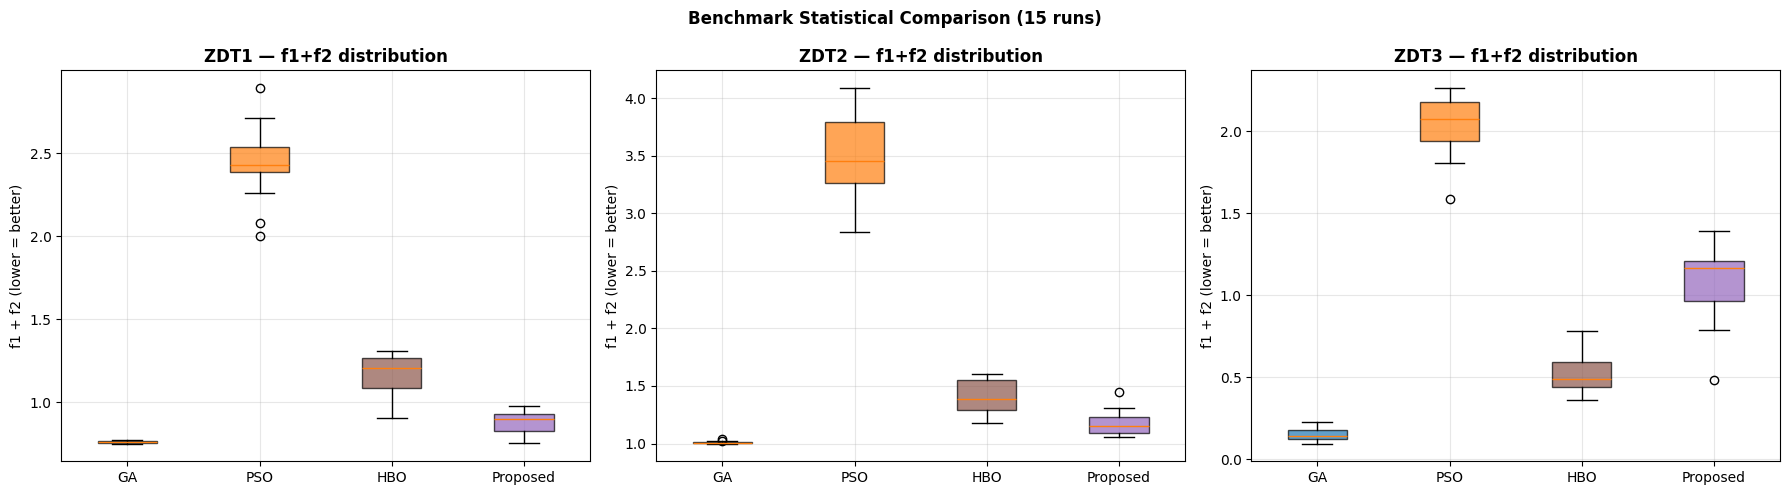

Saved: benchmark_stats.png


In [13]:
# ==========================================
# CELL 10: STATISTICAL COMPARISON ON ZDT BENCHMARKS
# ==========================================
import numpy as np
from scipy.stats import ranksums

def _bench_solver(func, strategy, n_var=10, pop=40, iters=60):
    P = np.random.rand(pop, n_var)
    def score(x):
        try:
            f1,f2 = func(x)
            if not (np.isfinite(f1) and np.isfinite(f2)): return 1e9
            return float(f1+f2)
        except Exception:
            return 1e9
    S = np.array([score(P[i]) for i in range(pop)])
    best = P[S.argmin()].copy(); best_s = S.min()

    for t in range(iters):
        Q = P.copy()
        if strategy == "GA":
            for i in range(pop):
                a,b = np.random.randint(0,pop,2)
                m = np.random.rand(n_var) > 0.5
                Q[i] = np.where(m, P[a], P[b])
                Q[i] += np.random.normal(0, 0.05, n_var)
        elif strategy == "PSO":
            w = 0.9 - 0.5*t/iters
            for i in range(pop):
                Q[i] = P[i] + w*np.random.rand(n_var)*(best - P[i])
        elif strategy == "HBO":
            for i in range(pop):
                move = (t*pop + i) % 5
                if move == 0:   Q[i] = P[i] + np.random.normal(0,0.08,n_var)
                elif move == 1: m=np.random.rand(n_var)<0.5; Q[i][m]=best[m]
                elif move == 2: k=max(1,n_var//10); idx=np.random.choice(n_var,k,replace=False); Q[i][idx]=np.random.rand(k)
                elif move == 3: Q[i] = np.random.rand(n_var)
                else:
                    a,b = np.random.randint(0,n_var,2); Q[i][a],Q[i][b]=Q[i][b],Q[i][a]
        elif strategy == "Proposed":
            for i in range(pop):
                Q[i] = P[i] + np.random.normal(0, 0.05, n_var)
                if np.random.rand() < 0.1:
                    Q[i] = 0.5*Q[i] + 0.5*best
        Q = np.clip(Q, 0, 1)
        NS = np.array([score(Q[i]) for i in range(pop)])
        imp = NS < S
        P[imp] = Q[imp]; S[imp] = NS[imp]
        if S.min() < best_s:
            best_s = S.min(); best = P[S.argmin()].copy()
    return best_s

ZDT = {'ZDT1': zdt1, 'ZDT2': zdt2, 'ZDT3': zdt3}
STRATEGIES = ["GA", "PSO", "HBO", "Proposed"]
N_RUNS = 15

print("="*60)
print(f"STATISTICAL BENCHMARK: ZDT1/2/3 | {N_RUNS} runs each")
print("="*60)
benchmark_results = {s: {b: [] for b in ZDT} for s in STRATEGIES}

for bname, bfn in ZDT.items():
    for s in STRATEGIES:
        for _ in range(N_RUNS):
            benchmark_results[s][bname].append(_bench_solver(bfn, s))
        mu = np.mean(benchmark_results[s][bname])
        sd = np.std(benchmark_results[s][bname])
        print(f"  {bname} | {s:<10}: mean f1+f2 = {mu:.4f} +/- {sd:.4f}")

print("\n--- Wilcoxon: Proposed vs others ---")
for bname in ZDT:
    for s in ["GA","PSO","HBO"]:
        stat, p = ranksums(benchmark_results[s][bname],
                           benchmark_results["Proposed"][bname])
        h = np.mean(benchmark_results["Proposed"][bname])
        o = np.mean(benchmark_results[s][bname])
        verdict = "WINS" if h < o else "loses"
        print(f"  {bname} | Proposed vs {s:<4}: p={p:.5f} "
              f"| delta={o-h:+.4f}  {verdict}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, bname in zip(axes, ZDT):
    data = [benchmark_results[s][bname] for s in STRATEGIES]
    bp = ax.boxplot(data, patch_artist=True, labels=STRATEGIES)
    for patch, c in zip(bp['boxes'], ['#1f77b4','#ff7f0e','#8c564b','#9467bd']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(f'{bname} — f1+f2 distribution', fontweight='bold')
    ax.set_ylabel('f1 + f2 (lower = better)'); ax.grid(True, alpha=0.3)
plt.suptitle(f'Benchmark Statistical Comparison ({N_RUNS} runs)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: benchmark_stats.png")

Concurrent workload: 5 jobs running simultaneously
Jobs: ['j_1218850', 'j_2429119', 'j_669567', 'j_1746985', 'j_3056239']

  Loading j_1218850...

2026-05-04 16:06:55,289 - INFO - Extracting DAG for Job: j_1218850


 +127 tasks
  Loading j_2429119...

2026-05-04 16:07:37,364 - INFO - Extracting DAG for Job: j_2429119


 +103 tasks
  Loading j_669567...

...

 +77 tasks
  Loading j_1746985...

2026-05-04 16:08:54,916 - INFO - Extracting DAG for Job: j_1746985


 +76 tasks
  Loading j_3056239...

2026-05-04 16:09:34,413 - INFO - Extracting DAG for Job: j_3056239


 +67 tasks

Concurrent workload size: 450 tasks
Env: 10 processors | HEFT=4279.5s | SLA=6419.2s

  EACH ALGORITHM SCHEDULES ALL 5 JOBS CONCURRENTLY
  (3 runs per algorithm)

  -- MO-GA scheduling all 5 jobs in parallel --
    Run 1: Mk=4471.7s | E=19192J | DMR=0.0% | Wait=3246.3s | Util=31.0%
    Run 2: Mk=4413.9s | E=19169J | DMR=0.0% | Wait=3070.6s | Util=31.4%
    Run 3: Mk=4454.2s | E=19141J | DMR=0.0% | Wait=3133.6s | Util=31.1%

  -- MO-PSO scheduling all 5 jobs in parallel --
    Run 1: Mk=4592.2s | E=19119J | DMR=0.0% | Wait=3274.2s | Util=30.2%
    Run 2: Mk=4533.0s | E=18663J | DMR=0.0% | Wait=3109.7s | Util=30.5%
    Run 3: Mk=4501.4s | E=19140J | DMR=0.0% | Wait=3228.9s | Util=30.8%

  -- MO-GWO scheduling all 5 jobs in parallel --
    Run 1: Mk=4626.5s | E=18564J | DMR=0.0% | Wait=3260.0s | Util=29.9%
    Run 2: Mk=4535.7s | E=18584J | DMR=0.0% | Wait=3296.8s | Util=30.5%
    Run 3: Mk=4356.8s | E=18811J | DMR=0.0% | Wait=2992.8s | Util=31.8%

  -- MO-EHO scheduling all 5 

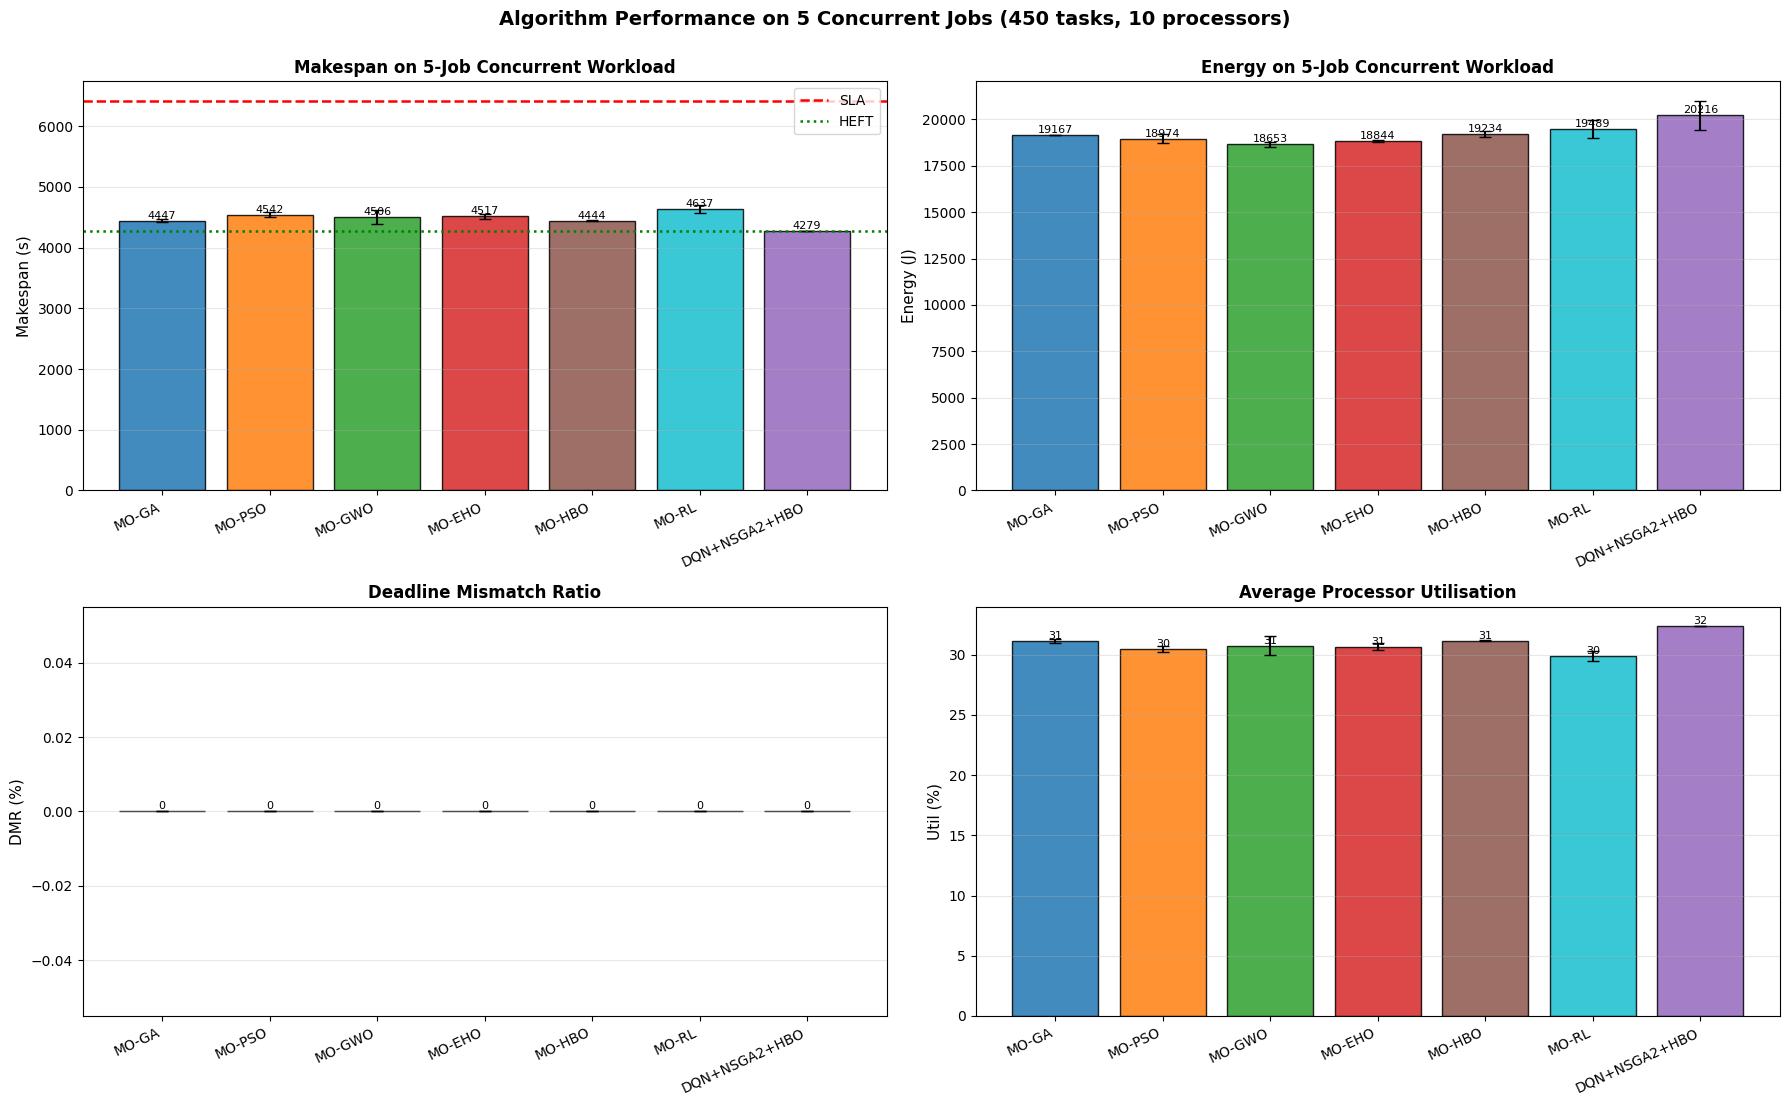


Saved: exp4_concurrent_workload.png


In [14]:
# ==========================================
# CELL 11: PARALLEL WORKLOAD (MO baselines)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

try:
    parallel_jobs
except NameError:
    raise RuntimeError("Run Cell 5 first — parallel_jobs is not defined.")

MAX_PARALLEL = min(5, len(parallel_jobs))
selected     = parallel_jobs[:MAX_PARALLEL]
print(f"Concurrent workload: {MAX_PARALLEL} jobs running simultaneously")
print(f"Jobs: {selected}\n")

concurrent_workload = []
for k, job in enumerate(selected):
    print(f"  Loading {job}...", end="", flush=True)
    job_tasks = preprocessor.load_job_dag(job)
    prefix    = f"J{k}_"
    for t in job_tasks:
        nt = Task(
            id           = prefix + t.id,
            c_w          = t.c_w,
            arrival_time = t.arrival_time,
            successors   = {prefix+k2: v for k2,v in t.successors.items()},
            predecessors = {prefix+k2: v for k2,v in t.predecessors.items()},
            pr           = t.pr,
        )
        concurrent_workload.append(nt)
    print(f" +{len(job_tasks)} tasks")

print(f"\nConcurrent workload size: {len(concurrent_workload)} tasks")

N_PARALLEL_PROCS = 10
small_procs = my_processors[:N_PARALLEL_PROCS]
small_env   = MultiprocessorEnvironment(small_procs, sla_multiplier=1.5)
sla         = small_env.compute_sla(concurrent_workload)
heft_m      = sla / small_env.sla_multiplier
print(f"Env: {N_PARALLEL_PROCS} processors | HEFT={heft_m:.1f}s | SLA={sla:.1f}s\n")

par_algos  = ["MO-GA","MO-PSO","MO-GWO","MO-EHO","MO-HBO","MO-RL", ALG_LABEL]
N_PAR_RUNS = 3
results    = {a: {'m':[], 'e':[], 'dmr':[], 'wait':[], 'util':[]} for a in par_algos}

print("="*70)
print(f"  EACH ALGORITHM SCHEDULES ALL {MAX_PARALLEL} JOBS CONCURRENTLY")
print(f"  ({N_PAR_RUNS} runs per algorithm)")
print("="*70)

for algo in par_algos:
    print(f"\n  -- {algo} scheduling all {MAX_PARALLEL} jobs in parallel --")
    for run in range(N_PAR_RUNS):
        if algo == ALG_LABEL:
            opt = ProposedOptimizer(small_env, concurrent_workload,
                                    pop_size=40, max_iter=80, n_objectives=3)
            r = opt.optimize()
            m, e, awt, util = r[1], r[2], r[3], r[4]
        else:
            algo_clean = algo.replace("MO-", "")
            opt = MOMetaheuristicOptimizer(small_env, concurrent_workload,
                                           pop_size=40, max_iter=80,
                                           algo_type=algo_clean, n_objectives=3)
            r = opt.optimize()
            m, e, awt, util = r[1], r[2], r[3], r[4]
        dmr = max(0.0, m-sla)/sla*100
        results[algo]['m']   .append(m)
        results[algo]['e']   .append(e)
        results[algo]['dmr'] .append(dmr)
        results[algo]['wait'].append(awt)
        results[algo]['util'].append(util)
        print(f"    Run {run+1}: Mk={m:.1f}s | E={e:.0f}J | DMR={dmr:.1f}% "
              f"| Wait={awt:.1f}s | Util={util*100:.1f}%")

print("\n" + "="*100)
print(f"  FINAL RESULTS — Each algorithm running {MAX_PARALLEL} jobs concurrently "
      f"on {N_PARALLEL_PROCS} procs")
print("="*100)
print(f"  {'Algorithm':<28} | {'Makespan (s)':>15} | {'Energy (J)':>12} "
      f"| {'DMR (%)':>9} | {'Wait (s)':>10} | {'Util (%)':>9} | {'Status':>14}")
print("  " + "-"*98)
for algo in par_algos:
    mu_m = np.mean(results[algo]['m']);    sd_m = np.std(results[algo]['m'])
    mu_e = np.mean(results[algo]['e'])
    mu_d = np.mean(results[algo]['dmr'])
    mu_w = np.mean(results[algo]['wait'])
    mu_u = np.mean(results[algo]['util'])*100
    short = algo.replace('Proposed(','').replace(')','')
    status = "BEATS SLA" if mu_m <= sla else "EXCEEDS SLA"
    print(f"  {short:<28} | {mu_m:>9.1f}+/-{sd_m:>4.1f} | {mu_e:>12.0f} "
          f"| {mu_d:>8.1f}% | {mu_w:>9.1f}s | {mu_u:>8.1f}% | {status:>14}")

col_map = {'MO-GA':'#1f77b4','MO-PSO':'#ff7f0e','MO-GWO':'#2ca02c',
           'MO-EHO':'#d62728','MO-HBO':'#8c564b','MO-RL':'#17becf',
           ALG_LABEL:'#9467bd'}
short_names = [a.replace('Proposed(','').replace(')','') for a in par_algos]
n_algos     = len(par_algos)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
panels = [
    (axes[0,0], 'm',    'Makespan (s)', 'Makespan on 5-Job Concurrent Workload'),
    (axes[0,1], 'e',    'Energy (J)',   'Energy on 5-Job Concurrent Workload'),
    (axes[1,0], 'dmr',  'DMR (%)',      'Deadline Mismatch Ratio'),
    (axes[1,1], 'util', 'Util (%)',     'Average Processor Utilisation'),
]
for ax, key, ylabel, title in panels:
    if key == 'util':
        means = [np.mean(results[a][key])*100 for a in par_algos]
        stds  = [np.std (results[a][key])*100 for a in par_algos]
    else:
        means = [np.mean(results[a][key]) for a in par_algos]
        stds  = [np.std (results[a][key]) for a in par_algos]
    bars = ax.bar(range(n_algos), means, yerr=stds,
                  color=[col_map[a] for a in par_algos],
                  alpha=0.85, capsize=4, edgecolor='black')
    if key == 'm':
        ax.axhline(sla, color='red', linestyle='--', linewidth=1.8, label='SLA')
        ax.axhline(heft_m, color='green', linestyle=':', linewidth=1.8, label='HEFT')
        ax.legend(fontsize=10)
    for i, b in enumerate(bars):
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h, f"{h:.0f}",
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(n_algos))
    ax.set_xticklabels(short_names, rotation=25, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Algorithm Performance on {MAX_PARALLEL} Concurrent Jobs '
             f'({len(concurrent_workload)} tasks, {N_PARALLEL_PROCS} processors)',
             fontweight='bold', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('exp4_concurrent_workload.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: exp4_concurrent_workload.png")

2026-05-06 11:07:58,772 - INFO - Extracting DAG for Job: j_139493


EXPERIMENT 5: PROCESSOR-COUNT SCALABILITY  (fixed job = j_139493)
  P sweep = [10, 25, 50, 100, 200] | Runs=3 | MaxIter=150 | Pop=50 | Obj=3


2026-05-06 11:08:58,861 - INFO - Loading processor metadata...
2026-05-06 11:08:58,904 - INFO - Generated 10 Processors.


  Fixed job: j_139493 | Tasks = ?

------------------------------------------------------------------------
  P = 10 processors
------------------------------------------------------------------------
  HEFT=7065.1s | SLA=10597.6s (HEFT x 1.5)
  GA                                 ...  Makespan=7463.3+/-14.4s | BEATS SLA | DMR=0.0% | Energy=85128J | Util=94.4%
  PSO                                ...  Makespan=7169.6+/-28.5s | BEATS SLA | DMR=0.0% | Energy=84693J | Util=98.2%
  GWO                                ...  Makespan=7409.2+/-84.4s | BEATS SLA | DMR=0.0% | Energy=85047J | Util=95.1%
  EHO                                ...  Makespan=7161.9+/-31.0s | BEATS SLA | DMR=0.0% | Energy=84681J | Util=98.4%
  HBO                                ...  Makespan=7273.1+/-13.1s | BEATS SLA | DMR=0.0% | Energy=84847J | Util=96.9%
  RL                                 ...  Makespan=7456.4+/-92.2s | BEATS SLA | DMR=0.0% | Energy=85117J | Util=94.5%
  Proposed(DQN+NSGA2+HBO)            ...

2026-05-06 11:14:08,489 - INFO - Loading processor metadata...


...

  Makespan=2849.8+/-1.8s | BEATS SLA | DMR=0.0% | Energy=84596J | Util=98.9%

------------------------------------------------------------------------
  P = 50 processors
------------------------------------------------------------------------
  HEFT=1441.1s | SLA=2161.6s (HEFT x 1.5)
  GA                                 ...  Makespan=2048.2+/-80.8s | BEATS SLA | DMR=0.0% | Energy=89123J | Util=68.9%
  PSO                                ...  Makespan=1884.4+/-14.4s | BEATS SLA | DMR=0.0% | Energy=87910J | Util=74.8%
  GWO                                ...  Makespan=1905.2+/-164.9s | BEATS SLA | DMR=0.0% | Energy=88067J | Util=74.5%
  EHO                                ...  Makespan=1876.2+/-3.4s | BEATS SLA | DMR=0.0% | Energy=87850J | Util=75.1%
  HBO                                ...  Makespan=1971.8+/-97.3s | BEATS SLA | DMR=0.0% | Energy=88558J | Util=71.6%
  RL                                 ...  Makespan=2092.2+/-89.4s | BEATS SLA | DMR=0.1% | Energy=89452J | Util=67.5%
  Prop

2026-05-06 11:54:29,258 - INFO - Loading processor metadata...
2026-05-06 11:54:29,317 - INFO - Generated 100 Processors.


  Makespan=1438.3+/-0.5s | BEATS SLA | DMR=0.0% | Energy=84620J | Util=97.9%

------------------------------------------------------------------------
  P = 100 processors
------------------------------------------------------------------------
  HEFT=745.2s | SLA=1117.9s (HEFT x 1.5)
  GA                                 ...  Makespan=1301.1+/-79.6s | EXCEEDS SLA | DMR=16.4% | Energy=93073J | Util=54.3%
  PSO                                ...  Makespan=1183.1+/-2.0s | EXCEEDS SLA | DMR=5.8% | Energy=91312J | Util=59.5%
  GWO                                ...  Makespan=1181.7+/-2.0s | EXCEEDS SLA | DMR=5.7% | Energy=91293J | Util=59.6%
  EHO                                ...  Makespan=1211.9+/-1.5s | EXCEEDS SLA | DMR=8.4% | Energy=91745J | Util=58.1%
  HBO                                ...  Makespan=1269.3+/-99.5s | EXCEEDS SLA | DMR=13.5% | Energy=92595J | Util=55.8%
  RL                                 ...  Makespan=1352.7+/-72.4s | EXCEEDS SLA | DMR=21.0% | Energy=93835J | Util=

2026-05-06 13:17:13,876 - INFO - Loading processor metadata...
2026-05-06 13:17:13,905 - INFO - Generated 200 Processors.


  Makespan=742.5+/-0.5s | BEATS SLA | DMR=0.0% | Energy=84802J | Util=94.9%

------------------------------------------------------------------------
  P = 200 processors
------------------------------------------------------------------------
  HEFT=484.5s | SLA=726.8s (HEFT x 1.5)
  GA                                 ...  Makespan=952.6+/-2.0s | EXCEEDS SLA | DMR=31.1% | Energy=101807J | Util=37.0%
  PSO                                ...  Makespan=809.4+/-88.5s | EXCEEDS SLA | DMR=11.4% | Energy=97490J | Util=44.0%
  GWO                                ...  Makespan=739.9+/-12.8s | EXCEEDS SLA | DMR=2.0% | Energy=95425J | Util=47.6%
  EHO                                ...  Makespan=944.2+/-3.9s | EXCEEDS SLA | DMR=29.9% | Energy=101508J | Util=37.3%
  HBO                                ...  Makespan=880.1+/-91.7s | EXCEEDS SLA | DMR=21.1% | Energy=99600J | Util=40.5%
  RL                                 ...  Makespan=951.2+/-0.0s | EXCEEDS SLA | DMR=30.9% | Energy=101737J | Util=37.

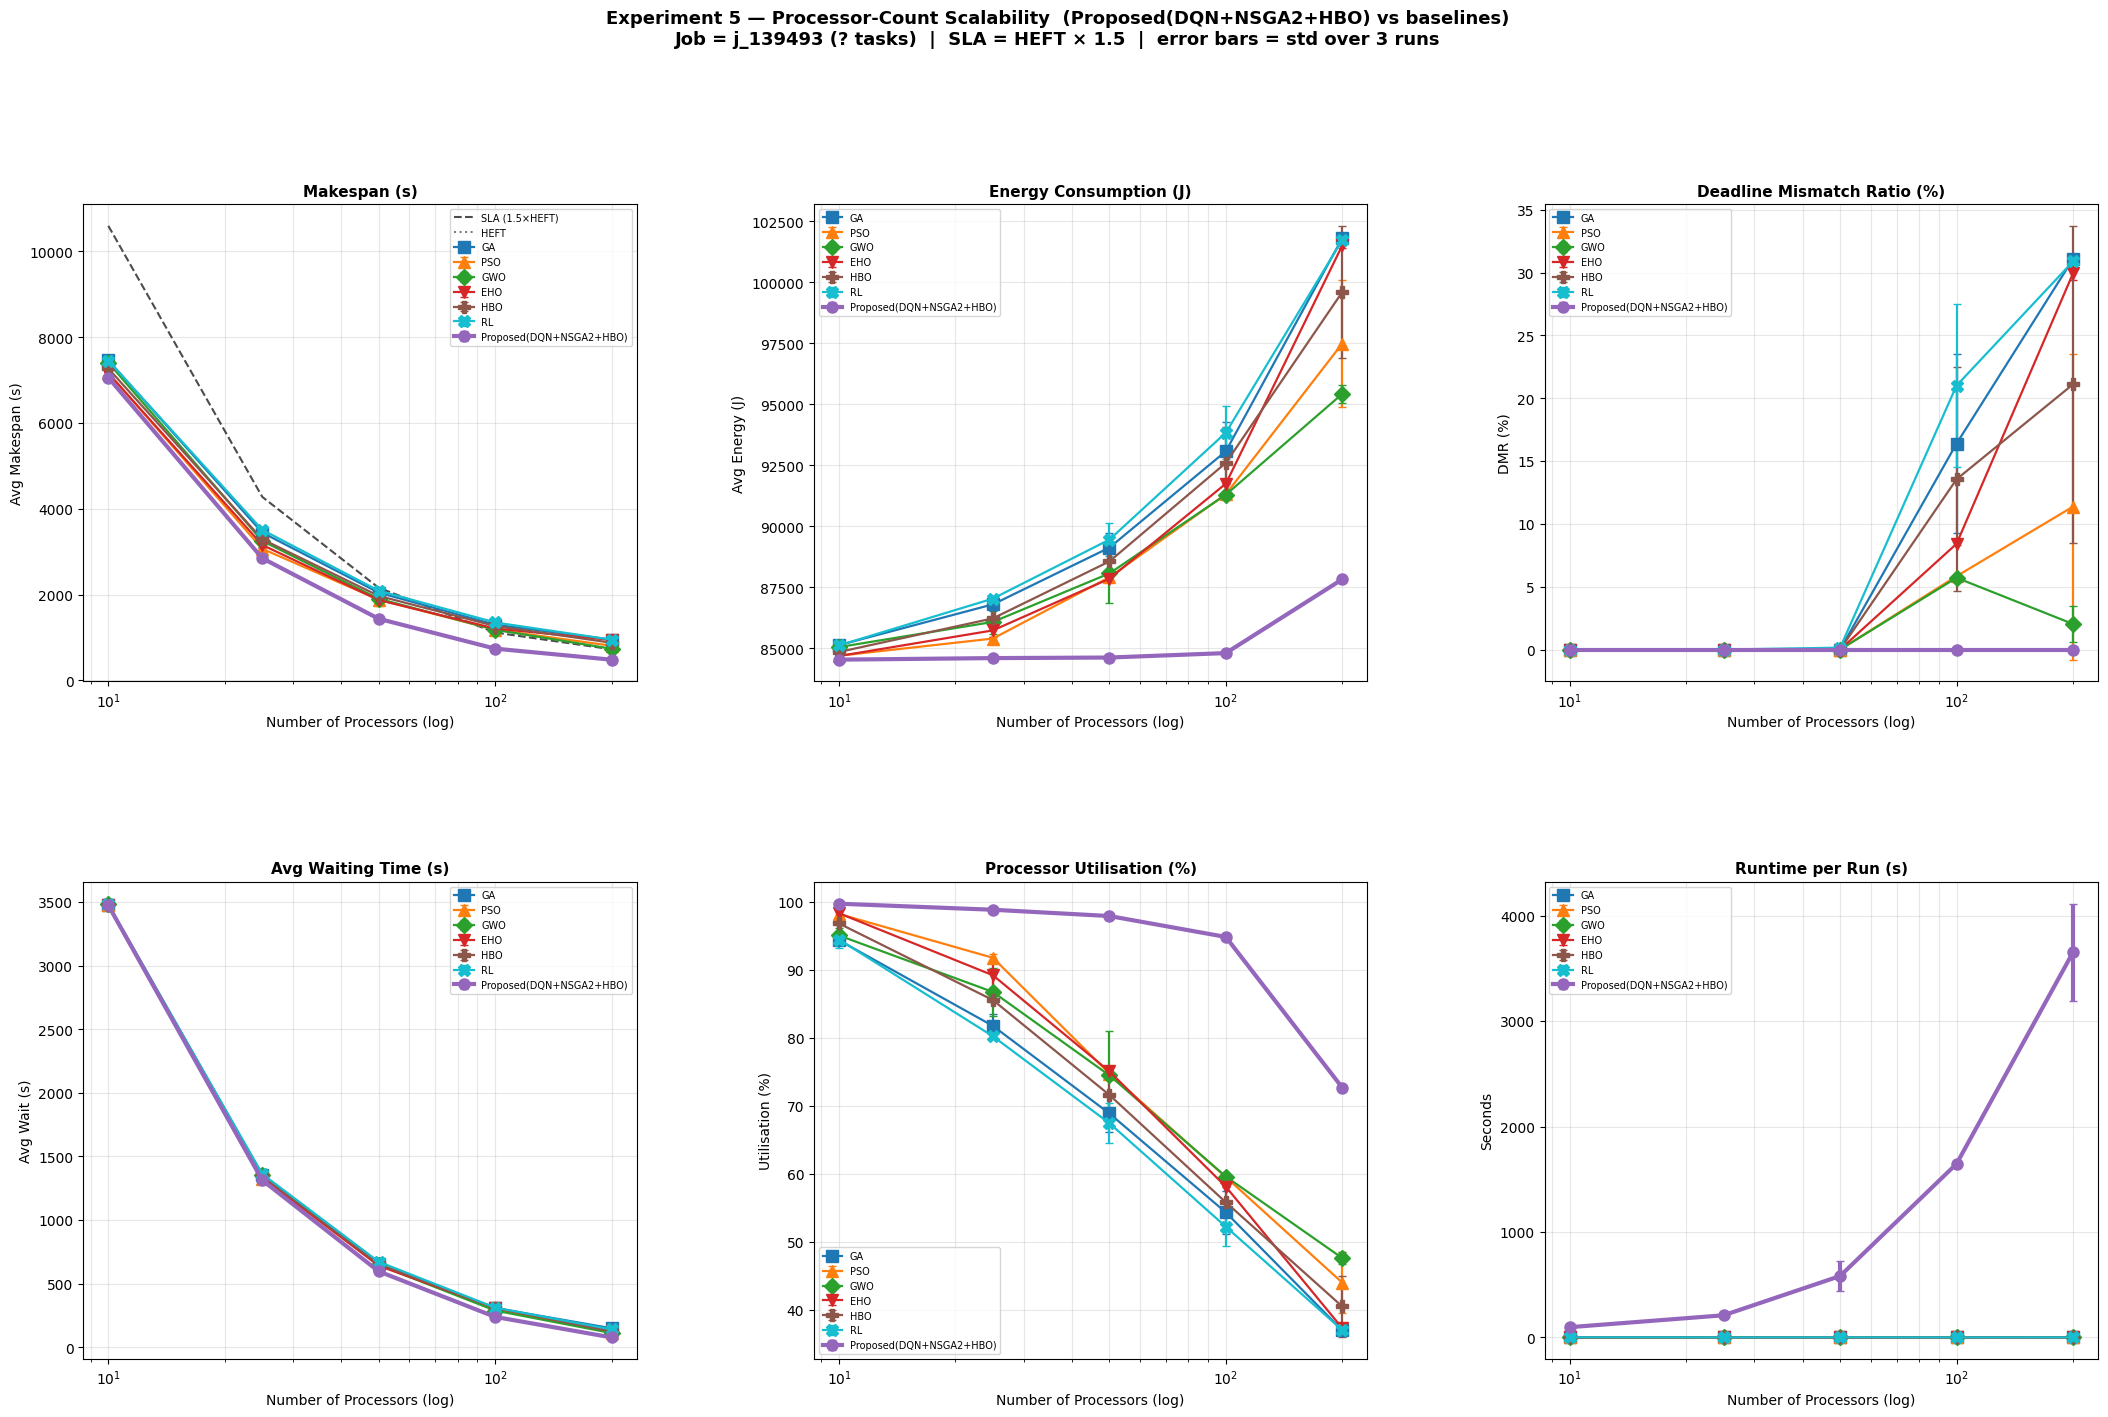


  FINAL RESULTS — Job j_139493 (? tasks) under varying P
     P |  HEFT(s) |   SLA(s) |       GA |      PSO |      GWO |      EHO |      HBO |       RL | Proposed
  ----------------------------------------------------------------------------------------------------------------
    10 |   7065.1 |  10597.6 |   7463.3 |   7169.6 |   7409.2 |   7161.9 |   7273.1 |   7456.4 |   7060.9
    25 |   2853.6 |   4280.4 |   3447.2 |   3069.5 |   3252.6 |   3159.4 |   3292.5 |   3511.1 |   2849.8
    50 |   1441.1 |   2161.6 |   2048.2 |   1884.4 |   1905.2 |   1876.2 |   1971.8 |   2092.2 |   1438.3
   100 |    745.2 |   1117.9 |   1301.1 |   1183.1 |   1181.7 |   1211.9 |   1269.3 |   1352.7 |    742.5
   200 |    484.5 |    726.8 |    952.6 |    809.4 |    739.9 |    944.2 |    880.1 |    951.2 |    484.5
Saved: exp5_processor_scalability.png


In [8]:
# ==========================================
# CELL 12: EXPERIMENT 5 — PROCESSOR-COUNT SCALABILITY
# Counterpart to Exp 1: holds the workload constant (j_139493, 301 tasks)
# and sweeps the processor pool size P. SLA is recomputed per P because
# HEFT depends on the cluster size.
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, time
warnings.filterwarnings("ignore")

# ─── Configuration ────────────────────────────────────────────────────
FIXED_JOB  = 'j_139493'            # 301 tasks (canonical job from Exp 3)
PROC_SWEEP = [10, 25, 50, 100, 200]
NUM_RUNS   = 3
MAX_ITER   = 150
POP_SIZE   = 50
N_OBJ      = 3
ALG_LABEL  = "Proposed(DQN+NSGA2+HBO)"
algorithms = ["GA", "PSO", "GWO", "EHO", "HBO", "RL", ALG_LABEL]

print("="*72)
print(f"EXPERIMENT 5: PROCESSOR-COUNT SCALABILITY  (fixed job = {FIXED_JOB})")
print(f"  P sweep = {PROC_SWEEP} | Runs={NUM_RUNS} | MaxIter={MAX_ITER} | Pop={POP_SIZE} | Obj={N_OBJ}")
print("="*72)

# Load the DAG once — workload stays constant across the sweep
my_dag = preprocessor.load_job_dag(FIXED_JOB)
def _ntasks(dag):
    for attr in ('num_tasks','n_tasks'):
        if hasattr(dag, attr):
            v = getattr(dag, attr)
            return v() if callable(v) else v
    for attr in ('tasks','task_list','nodes'):
        if hasattr(dag, attr):
            v = getattr(dag, attr)
            try: return len(v)
            except: pass
    return None
n_tasks = _ntasks(my_dag) or '?'
print(f"  Fixed job: {FIXED_JOB} | Tasks = {n_tasks}")

metrics   = ['makespan','energy','wait','util','dmr','runtime']
res       = {a: {m: [] for m in metrics} for a in algorithms}
res_std   = {a: {m: [] for m in metrics} for a in algorithms}
sla_list  = []
heft_list = []

for P in PROC_SWEEP:
    print(f"\n{'-'*72}")
    print(f"  P = {P} processors")
    print(f"{'-'*72}")
    procs, _    = preprocessor.load_processors(sample_size=P)
    environment = MultiprocessorEnvironment(procs, sla_multiplier=1.5)
    sla    = environment.compute_sla(my_dag)
    heft_m = sla / environment.sla_multiplier
    sla_list.append(sla); heft_list.append(heft_m)
    print(f"  HEFT={heft_m:.1f}s | SLA={sla:.1f}s (HEFT x 1.5)")

    for algo in algorithms:
        mk_r,en_r,wt_r,ut_r,dmr_r,rt_r=[],[],[],[],[],[]
        print(f"  {algo:<35}", end="", flush=True)
        for _ in range(NUM_RUNS):
            t0=time.time()
            if algo==ALG_LABEL:
                opt    = ProposedOptimizer(environment, my_dag,
                                           pop_size=POP_SIZE, max_iter=MAX_ITER,
                                           n_objectives=N_OBJ)
                result = opt.optimize()
                m,e,awt,util = result[1],result[2],result[3],result[4]
            else:
                opt = MetaheuristicOptimizer(environment, my_dag,
                                             pop_size=POP_SIZE, max_iter=MAX_ITER,
                                             algo_type=algo)
                _,m,e,awt,util,_,_ = opt.optimize()
            rt  = time.time()-t0
            dmr = max(0.0, m-sla)/sla*100
            mk_r.append(m); en_r.append(e); wt_r.append(awt)
            ut_r.append(util); dmr_r.append(dmr); rt_r.append(rt)
            print(".", end="", flush=True)

        for lst,key in [(mk_r,'makespan'),(en_r,'energy'),(wt_r,'wait'),
                         (ut_r,'util'),(dmr_r,'dmr'),(rt_r,'runtime')]:
            res[algo][key].append(np.mean(lst))
            res_std[algo][key].append(np.std(lst))

        status = "BEATS SLA" if np.mean(mk_r) <= sla else "EXCEEDS SLA"
        print(f"  Makespan={np.mean(mk_r):.1f}+/-{np.std(mk_r):.1f}s"
              f" | {status} | DMR={np.mean(dmr_r):.1f}%"
              f" | Energy={np.mean(en_r):.0f}J | Util={np.mean(ut_r)*100:.1f}%")

# ── Plots ─────────────────────────────────────────────────────────────
colors  = {'GA':'#1f77b4','PSO':'#ff7f0e','GWO':'#2ca02c',
           'EHO':'#d62728','HBO':'#8c564b','RL':'#17becf',
           ALG_LABEL:'#9467bd'}
markers = {'GA':'s','PSO':'^','GWO':'D','EHO':'v',
           'HBO':'P','RL':'X', ALG_LABEL:'o'}

fig = plt.figure(figsize=(26,15))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.42,wspace=0.32)
axes= [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(3)]

panels = [
    ('makespan','Makespan (s)',              'Avg Makespan (s)'),
    ('energy',  'Energy Consumption (J)',    'Avg Energy (J)'),
    ('dmr',     'Deadline Mismatch Ratio (%)','DMR (%)'),
    ('wait',    'Avg Waiting Time (s)',       'Avg Wait (s)'),
    ('util',    'Processor Utilisation (%)',  'Utilisation (%)'),
    ('runtime', 'Runtime per Run (s)',        'Seconds'),
]
for ax,(key,title,ylabel) in zip(axes,panels):
    for a in algorithms:
        vals  = res[a][key]; stds = res_std[a][key]
        yvals = [v*100 if key=='util' else v for v in vals]
        yerr  = [s*100 if key=='util' else s for s in stds]
        lw    = 3 if a==ALG_LABEL else 1.6
        ax.errorbar(PROC_SWEEP, yvals, yerr=yerr,
                    label=a, color=colors[a], marker=markers[a],
                    linewidth=lw, markersize=8, capsize=3,
                    zorder=3 if a==ALG_LABEL else 2)
    if key=='makespan':
        ax.plot(PROC_SWEEP, sla_list,  'k--', alpha=0.7, label='SLA (1.5×HEFT)')
        ax.plot(PROC_SWEEP, heft_list, 'k:',  alpha=0.5, label='HEFT')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Number of Processors (log)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=7)

plt.suptitle(f'Experiment 5 — Processor-Count Scalability  ({ALG_LABEL} vs baselines)\n'
             f'Job = {FIXED_JOB} ({n_tasks} tasks)  |  SLA = HEFT × 1.5  |  error bars = std over {NUM_RUNS} runs',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('exp5_processor_scalability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print("\n" + "="*112)
print(f"  FINAL RESULTS — Job {FIXED_JOB} ({n_tasks} tasks) under varying P")
print("="*112)
print(f"  {'P':>4} | {'HEFT(s)':>8} | {'SLA(s)':>8} | "
      + " | ".join(f"{a[:8]:>8}" for a in algorithms))
print("  " + "-"*112)
for i, P in enumerate(PROC_SWEEP):
    row = f"  {P:>4} | {heft_list[i]:>8.1f} | {sla_list[i]:>8.1f} | "
    row += " | ".join(f"{res[a]['makespan'][i]:>8.1f}" for a in algorithms)
    print(row)
print("="*112)
print("Saved: exp5_processor_scalability.png")